<a href="https://colab.research.google.com/github/hongxu-yn/Southeast-Asia-XCO2-STK/blob/main/%E7%BB%93%E6%9E%9C%E9%AA%8C%E8%AF%81.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#初始化

In [26]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

!pip install -q netCDF4 joblib tqdm xarray pykrige gstools cartopy scipy
!pip install regionmask geopandas geodatasets

import glob
import os
import xarray as xr
import pandas as pd
import numpy as np
from pathlib import Path
import warnings

PROJECT_DIR = Path("//content/drive/MyDrive/Southeast_Asia_XCO2_STK")
stk_nc = PROJECT_DIR / "step04_stk_fill/oco2_xco2_month_2014_2014_stk_SEA.nc"

Mounted at /content/drive


# 统计图表 初始化

In [34]:
import math
import shutil
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib.dates as mdates
from mpl_toolkits.axes_grid1 import make_axes_locatable
from scipy import stats
from scipy.stats import linregress, gaussian_kde
from sklearn.metrics import mean_squared_error

# 忽略警告
warnings.filterwarnings("ignore")

def setup_fonts():
    font_map = {
        "Times.ttf": "/content/drive/MyDrive/fonts/TimesNewRoman.ttf",
        "SimSun.ttf": "/content/drive/MyDrive/fonts/SimSun.ttf"
    }

    props = {"en": None, "cn": None}

    for name, drive_p in font_map.items():
        local_p = Path(f"/content/{name}")
        if Path(drive_p).exists():
            if not local_p.exists():
                shutil.copy(drive_p, local_p)
            fm.fontManager.addfont(str(local_p))
            if "Times" in name: props["en"] = fm.FontProperties(fname=str(local_p))
            else: props["cn"] = fm.FontProperties(fname=str(local_p))

    plt.rcParams.update({
        "font.family": "serif",
        "font.serif": ["Times New Roman", "SimSun"],
        "mathtext.fontset": "stix",
        "axes.unicode_minus": False,
        "font.size": 10
    })
    return props["en"], props["cn"]

prop_en, prop_cn = setup_fonts()

def plot_scatter(ax, df, x_name, y_name, title_name, x_label, y_label, sublabel="a", fontsize=10):
    data = df[[x_name, y_name]].dropna()
    x, y = data[x_name].values, data[y_name].values

    if len(x) < 2:
        ax.set_title(f"({sublabel}) {title_name}\n数据不足", fontsize=fontsize, fontweight='bold', fontproperties=prop_cn)
        return

    rmse = np.sqrt(mean_squared_error(x, y))
    bias = np.mean(y - x)
    slope, intercept, r_val, _, _ = stats.linregress(x, y)
    r2 = r_val ** 2

    # 绘图
    ax.scatter(x, y, s=15, facecolor="#9ecae1", edgecolor="#3182bd", linewidth=0.7, alpha=0.85, zorder=2)
    d_min, d_max = min(x.min(), y.min()), max(x.max(), y.max())
    pad = (d_max - d_min) * 0.3
    v_min, v_max = d_min - pad, d_max + pad
    ax.set_xlim([v_min, v_max]); ax.set_ylim([v_min, v_max])
    ax.set_aspect('equal', adjustable='box')

    xx = np.array([v_min, v_max])
    ax.plot(xx, xx, '--', lw=1.1, color="#7f7f7f", zorder=1)
    ax.plot(xx, slope * xx + intercept, '-', lw=1.6, color="#08519c", zorder=3)

    ax.set_title(f'({sublabel}) {title_name}', fontsize=fontsize, fontweight='bold', fontproperties=prop_en)
    ax.set_xlabel(x_label, fontsize=fontsize, fontproperties=prop_en)
    ax.set_ylabel(y_label, fontsize=fontsize, fontproperties=prop_en)

    stats_text = (f'$N$ = {len(x)}\n$R^2$ = {r2:.3f}\nRMSE = {rmse:.2f} ppm\n'
                  f'Bias = {bias:.2f} ppm\n$y$ = {slope:.2f}$x$ + {intercept:.2f}')
    ax.text(0.02, 0.98, stats_text, transform=ax.transAxes, fontsize=fontsize-4,
            verticalalignment='top', family='monospace',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='none', linewidth=0))

    ax.tick_params(axis='both', labelsize=fontsize, direction='out', length=4)
    if prop_en:
        p_en = prop_en.copy(); p_en.set_size(fontsize)
        for t in ax.get_xticklabels() + ax.get_yticklabels(): t.set_fontproperties(p_en)

def plot_density_scatter(ax, df, x_name, y_name, title_name,
                         x_label, y_label, sublabel="a", fontsize=10):
    data = df[[x_name, y_name]].dropna()
    x = data[x_name].values
    y = data[y_name].values

    if len(x) < 2:
        ax.set_title(f"({sublabel}) {title_name}\n数据不足",
                     fontsize=fontsize+2, fontweight='bold',
                     fontproperties=prop_en)
        return None, False

    rmse = np.sqrt(mean_squared_error(x, y))
    bias = np.mean(y - x)
    slope, intercept, r_val, _, _ = stats.linregress(x, y)
    r2 = r_val ** 2

    use_density = True
    try:
        xy = np.vstack([x, y])
        z = gaussian_kde(xy)(xy)
        idx = z.argsort()
        x, y, z = x[idx], y[idx], z[idx]
    except Exception:
        use_density = False
        z = None

    # =========================
    # 3. 坐标范围
    # =========================
    d_min = min(x.min(), y.min())
    d_max = max(x.max(), y.max())
    pad = (d_max - d_min) * 0.4
    v_min, v_max = d_min - pad, d_max + pad

    ax.set_xlim([v_min, v_max])
    ax.set_ylim([v_min, v_max])
    ax.set_aspect('equal', adjustable='box')


    if use_density:
        sc = ax.scatter(
            x, y, c=z, s=10, cmap='Spectral_r',
            edgecolor='none', alpha=0.85, zorder=2
        )
    else:
        sc = ax.scatter(
            x, y, s=15, facecolor="#9ecae1",
            edgecolor="#3182bd", linewidth=0.4,
            alpha=0.85, zorder=2
        )

    # =========================
    # 5. 1:1线 和 拟合线
    # =========================
    xx = np.array([v_min, v_max])
    ax.plot(xx, xx, '--', lw=1.1, color="#7f7f7f", zorder=1)
    ax.plot(xx, slope * xx + intercept, '-', lw=1.6, color="black", zorder=3)


    ax.set_title(f'{sublabel}{title_name}',
                 fontsize=fontsize+2, fontweight='bold',
                 fontproperties=prop_en if all(ord(c) < 128 for c in title_name) else prop_en)

    ax.set_xlabel(x_label, fontsize=fontsize, fontproperties=prop_en)
    ax.set_ylabel(y_label, fontsize=fontsize, fontproperties=prop_en)

    # =========================
    # 7. 统计文本框
    # =========================
    sign = "+" if intercept >= 0 else "-"
    stats_text = (
        f'$N$ = {len(x)}\n'
        f'$R^2$ = {r2:.3f}\n'
        f'RMSE = {rmse:.2f} ppm\n'
        f'Bias = {bias:.2f} ppm\n'
        f'$y$ = {slope:.2f}$x$ {sign} {abs(intercept):.2f}'
    )
    ax.text(
        0.03, 0.97, stats_text,
        transform=ax.transAxes,
        fontsize=fontsize-2,
        verticalalignment='top',
        family='serif',
        bbox=dict(boxstyle='round', facecolor='none',
                  alpha=0.90, edgecolor='none', linewidth=0)
    )

    ax.tick_params(axis='both', labelsize=fontsize, direction='out', length=4)
    if prop_en:
        p_en = prop_en.copy()
        p_en.set_size(fontsize-1)
        for t in ax.get_xticklabels() + ax.get_yticklabels():
            t.set_fontproperties(p_en)

    return sc, use_density



# 读取TCCON NC-CSV

In [93]:
import xarray as xr
import pandas as pd
from pathlib import Path

TCCON_PATH = Path("/content/drive/MyDrive/xco2_datasets_conduct/co2_obs/TCCON")
SAVE_DIR = PROJECT_DIR / "step05_Validation/TCCON"
SAVE_DIR.mkdir(parents=True, exist_ok=True)

STATIONS = {"hf": "Hefei", "bu": "Burgos"}
FILES = ["hf20151102_20241229.public.qc.nc", "bu20170303_20231228.public.qc.nc"]

def read_tccon(filepath, station_name, offset=8):
    if not filepath.exists(): return pd.DataFrame()

    with xr.open_dataset(filepath, decode_timedelta=False) as ds:
        df = pd.DataFrame({'time': pd.to_datetime(ds.time.values),
                           'xco2': ds.xco2.values.flatten()}).dropna()
        lat, lon = float(ds.lat[0]), float(ds.long[0])

    # 转换当地时间 -> 筛选 12-14h -> 按月聚合 Mean
    return (df.assign(local_t=df['time'] + pd.Timedelta(hours=offset))
            .query('12 <= local_t.dt.hour <= 14')
            .resample('ME', on='time')['xco2'].mean()
            .reset_index().rename(columns={'xco2': 'XCO2'})
            .assign(site=station_name, lat=lat, lon=lon))

for f in FILES:
    name = STATIONS.get(f[:2])
    df = read_tccon(TCCON_PATH / f, name)

    if not df.empty:
        out_csv = SAVE_DIR / f"TCCON_{name}_12-14h_monthly.csv"
        df.to_csv(out_csv, index=False)
        print(f"✅ Saved: {name} -> {out_csv}")


✅ Saved: Hefei -> /content/drive/MyDrive/Southeast_Asia_XCO2_STK/step05_Validation/TCCON/TCCON_Hefei_12-14h_monthly.csv
✅ Saved: Burgos -> /content/drive/MyDrive/Southeast_Asia_XCO2_STK/step05_Validation/TCCON/TCCON_Burgos_12-14h_monthly.csv


# 读取WDCGG NC-CSV

In [92]:
import xarray as xr
import pandas as pd
import numpy as np
from pathlib import Path

# ==========================================
# 1. 配置路径与站点
# ==========================================
PROJECT_DIR = Path("/content/drive/MyDrive/Southeast_Asia_XCO2_STK")
WGDCC_PATH = Path("/content/drive/MyDrive/xco2_datasets_conduct/co2_obs/WDCGG_CO2/co2/monthly")
SAVE_DIR = PROJECT_DIR / "step05_Validation/WDCGG"
SAVE_DIR.mkdir(parents=True, exist_ok=True)

datetype = "month"
# 目标站点列表
sites = ['BKT', 'HAT', 'HKG', 'HKO', 'LLN', 'YON']


def read_wdcgg_monthly_nc(file_path):
    """
    Reads WDCGG monthly NetCDF files, specifically handling the 'months since'
    time unit error and standardizing for satellite validation.
    """
    # 1. Open with decode_times=False to avoid the 'months since' ValueError
    ds = xr.open_dataset(file_path, decode_times=False)

    # 2. Manual Time Parsing
    units = ds.time.attrs.get('units', "")

    if "months since" in units:
        # Extract base date (e.g., '1988-04-01 00:00:00')
        base_date_str = units.split("since ")[1].split(" +")[0].strip()
        base_date = pd.to_datetime(base_date_str)
        # Apply pd.DateOffset for varying month lengths
        times = [base_date + pd.DateOffset(months=int(m)) for m in ds.time.values]
    else:
        # Fallback for standard units (hours/days) using xarray's internal decoder
        ds_decoded = xr.decode_cf(ds)
        times = ds_decoded.time.values

    # 3. Extract Variable and Metadata
    # WDCGG flask files usually use 'value', in-situ often use 'co2'
    var_name = next((v for v in ['value', 'co2', 'parameter_value'] if v in ds.data_vars), None)

    if var_name is None:
        ds.close()
        return pd.DataFrame()

    # Extract coordinates from attributes or variables
    lat = float(np.atleast_1d(ds.attrs.get('latitude', ds.get('latitude', 0)))[0])
    lon = float(np.atleast_1d(ds.attrs.get('longitude', ds.get('longitude', 0)))[0])

    # Attempt to get site ID from attributes, otherwise use filename stem
    site_id = ds.attrs.get('site_code', Path(file_path).stem.split('_')[1]).upper()

    # 4. Construct DataFrame
    df = pd.DataFrame({
        'time': times,
        'co2': ds[var_name].values.flatten()
    })

    # 5. Standardization & Cleaning
    # Strip timezones
    df['time'] = pd.to_datetime(df['time']).dt.tz_localize(None)

    # Force to 1st of the month for satellite matching
    df['time'] = df['time'].dt.to_period('M').dt.to_timestamp()

    # Filter valid range and drop missing values (WDCGG fill value is ~9.9e33)
    df = df.dropna().query("300 < co2 < 600").copy()

    # Add Metadata
    df['site'] = site_id
    df['lat'] = lat
    df['lon'] = lon

    ds.close()
    return df



# 3. 批量处理循环
# ==========================================
print(f"🚀 Starting WDCGG processing for sites: {sites}")

# 获取目录下所有满足条件的 .nc 文件
files = sorted(WGDCC_PATH.glob(f"co2_*_surface*_{datetype}*.nc"))

for f in files:
    # 过滤掉气象辅助文件
    if "_met.nc" in f.name:
        continue


    try:
        raw_sid = f.name.split('_')[1].upper()
        # 进一步清洗，只保留字母
        sid = "".join(filter(str.isalpha, raw_sid))
    except IndexError:
        continue

    # 如果站点在我们的目标列表中
    if sid in sites:
        try:
            df_site = read_wdcgg_monthly_nc(f)
            if not df_site.empty:
                out_path = SAVE_DIR / f"WDCGG_{sid}_{f.name.split('_')[2]}_{datetype}.csv"
                df_site.to_csv(out_path, index=False)
                print(f"✅ Saved: {out_path.name} ({len(df_site)} records)")
        except Exception as e:
            print(f"❌ Error processing {f.name}: {e}")

print("\n✨ All specified WDCGG sites processed.")

🚀 Starting WDCGG processing for sites: ['BKT', 'HAT', 'HKG', 'HKO', 'LLN', 'YON']
✅ Saved: WDCGG_BKT_surface-flask_month.csv (230 records)
✅ Saved: WDCGG_BKT_surface-insitu_month.csv (102 records)
✅ Saved: WDCGG_HAT_surface-insitu_month.csv (378 records)
✅ Saved: WDCGG_HKG_surface-insitu_month.csv (176 records)
✅ Saved: WDCGG_HKO_surface-insitu_month.csv (185 records)
✅ Saved: WDCGG_LLN_surface-flask_month.csv (219 records)
✅ Saved: WDCGG_YON_surface-insitu_month.csv (326 records)

✨ All specified WDCGG sites processed.


In [95]:
import xarray as xr
import pandas as pd
import numpy as np
from pathlib import Path

# ==========================================
# 1. 核心处理函数：读取并标准化 WDCGG NC 文件
# ==========================================
def read_wdcgg_monthly_nc(file_path):
    """
    处理 WDCGG 复杂的 'months since' 时间格式并标准化坐标和变量名
    """
    # decode_times=False 避免解析错误
    ds = xr.open_dataset(file_path, decode_times=False)

    # --- 时间解析 ---
    units = ds.time.attrs.get('units', "")
    if "months since" in units:
        base_date_str = units.split("since ")[1].split(" +")[0].strip()
        base_date = pd.to_datetime(base_date_str)
        times = [base_date + pd.DateOffset(months=int(m)) for m in ds.time.values]
    else:
        # 如果是标准单位则使用 xarray 默认解析
        ds_decoded = xr.decode_cf(ds)
        times = ds_decoded.time.values

    # --- 变量识别 ---
    var_name = next((v for v in ['value', 'co2', 'parameter_value'] if v in ds.data_vars), None)
    if var_name is None:
        ds.close()
        return pd.DataFrame()

    # --- 坐标获取 ---
    lat = float(np.atleast_1d(ds.attrs.get('latitude', ds.get('latitude', 0)))[0])
    lon = float(np.atleast_1d(ds.attrs.get('longitude', ds.get('longitude', 0)))[0])
    # 提取站点缩写 (如 TER, YON)
    site_id = ds.attrs.get('site_code', Path(file_path).stem.split('_')[1]).upper()

    # --- 构建标准化 DataFrame ---
    df = pd.DataFrame({
        'time': pd.to_datetime(times).tz_localize(None), # 去除时区
        'Ground_CO2': ds[var_name].values.flatten()
    })

    # 强制归一化为当月 1 号，确保能与卫星数据 merge
    df['time'] = df['time'].dt.to_period('M').dt.to_timestamp()

    # 基础清洗
    df = df.dropna().query("300 < Ground_CO2 < 600").copy()
    df['site'], df['lat'], df['lon'] = site_id, lat, lon

    ds.close()
    return df

# ==========================================
# 2. 匹配逻辑与主程序
# ==========================================
PROJECT_DIR = Path("/content/drive/MyDrive/Southeast_Asia_XCO2_STK")
WGDCC_RAW_DIR = Path("/content/drive/MyDrive/xco2_datasets_conduct/co2_obs/WDCGG_CO2/co2/monthly")
Validation_DIR = PROJECT_DIR / "step05_Validation"
match_csv = Validation_DIR / "Matched_stk_xco2_WDCGG.csv"

# 读取卫星数据
SAT_PATH = PROJECT_DIR / "step04_stk_fill/oco2_xco2_month_2014_2014_stk_SEA.nc" # 请确认此文件包含目标年份
ds_sat = xr.open_dataset(SAT_PATH)
sat_var = 'xco2'

# 标准化卫星时间轴（确保也是当月1号）
sat_time_coords = pd.to_datetime(ds_sat.time.values).tz_localize(None)
ds_sat.coords['time'] = pd.Series(sat_time_coords).dt.to_period('M').dt.to_timestamp().values

matched_list = []
# 获取所有 WDCGG NC 文件
all_nc_files = list(WGDCC_RAW_DIR.glob("*.nc"))

print(f"开始星地匹配，共搜索到 {len(all_nc_files)} 个站点文件...")

for f_path in all_nc_files:
    if "_met.nc" in f_path.name: continue # 跳过气象辅助文件

    try:
        # 1. 读取并标准化地基数据
        df_ground = read_wdcgg_monthly_nc(f_path)
        if df_ground.empty: continue

        st_lat, st_lon = df_ground['lat'].iloc[0], df_ground['lon'].iloc[0]
        st_name = df_ground['site'].iloc[0]

        # 2. 空间匹配：在卫星数据中寻找最近的格点
        # 使用 method='nearest' 提取该站点的卫星时间序列
        ds_pixel = ds_sat[sat_var].sel(lat=st_lat, lon=st_lon, method='nearest')
        df_sat = ds_pixel.to_dataframe().reset_index()

        # 卫星数据列名清洗
        df_sat = df_sat.rename(columns={sat_var: 'STK_XCO2'})
        df_sat['time'] = pd.to_datetime(df_sat['time']).dt.tz_localize(None)

        # 3. 时间匹配：内连接 (Inner Join)
        df_m = pd.merge(df_ground, df_sat[['time', 'STK_XCO2']], on='time', how='inner')

        if not df_m.empty:
            matched_list.append(df_m)
            print(f"✅ 站点 {st_name}: 成功匹配 {len(df_m)} 条记录")
        else:
            # 诊断：如果没有匹配上，通常是时间段不重叠
            g_min, g_max = df_ground['time'].min().year, df_ground['time'].year.max()
            print(f"⚠️ 站点 {st_name}: 时间轴无重叠 ({g_min}-{g_max})")

    except Exception as e:
        print(f"❌ 处理失败 {f_path.name}: {e}")

# ==========================================
# 3. 结果汇总与保存
# ==========================================
if matched_list:
    df_final = pd.concat(matched_list, ignore_index=True)
    df_final.to_csv(match_csv, index=False)
    print("\n" + "="*30)
    print(f"🎉 匹配完成！")
    print(f"总计匹配站点数: {df_final['site'].nunique()}")
    print(f"总计记录条数: {len(df_final)}")
    print(f"结果已保存至: {match_csv}")
else:
    print("\n❌ 匹配结果为空，请检查地基数据与卫星数据的时间段是否有重叠。")

开始星地匹配，共搜索到 370 个站点文件...
✅ 站点 KIS2017: 成功匹配 103 条记录
✅ 站点 DDR2019: 成功匹配 103 条记录
❌ 处理失败 co2_urw2020_surface-insitu_65_9999-9999_monthly.nc: 'Series' object has no attribute 'year'
❌ 处理失败 co2_cgo5011_surface-insitu_16_9997-9999_monthly.nc: 'Series' object has no attribute 'year'
❌ 处理失败 co2_cgo5011_surface-insitu_16_9998-9999_monthly.nc: 'Series' object has no attribute 'year'
✅ 站点 CGO5011: 成功匹配 64 条记录
✅ 站点 MQA5015: 成功匹配 27 条记录
❌ 处理失败 co2_jbn7002_surface-insitu_18_9999-9999_monthly.nc: 'Series' object has no attribute 'year'
✅ 站点 CAI1001: 成功匹配 15 条记录
✅ 站点 FRF1012: 成功匹配 50 条记录
✅ 站点 CHL4004: 成功匹配 61 条记录
❌ 处理失败 co2_cdl4008_surface-insitu_20_9999-9999_monthly.nc: 'Series' object has no attribute 'year'
❌ 处理失败 co2_chm4012_surface-insitu_20_9999-9999_monthly.nc: 'Series' object has no attribute 'year'
✅ 站点 BCK4129: 成功匹配 89 条记录
✅ 站点 CBY4165: 成功匹配 77 条记录
✅ 站点 LMP6051: 成功匹配 66 条记录
✅ 站点 LMP6051: 成功匹配 99 条记录
✅ 站点 MDN6418: 成功匹配 80 条记录
✅ 站点 TIK2002: 成功匹配 80 条记录
✅ 站点 PAL6004: 成功匹配 112 条记录
❌ 处理失败 co2_kps

In [91]:
import xarray as xr
import pandas as pd
import numpy as np
from pathlib import Path

def read_wdcgg_monthly_nc(file_path):
    """
    Reads WDCGG monthly NetCDF files, specifically handling the 'months since'
    time unit error and standardizing for satellite validation.
    """
    # 1. Open with decode_times=False to avoid the 'months since' ValueError
    ds = xr.open_dataset(file_path, decode_times=False)

    # 2. Manual Time Parsing
    units = ds.time.attrs.get('units', "")

    if "months since" in units:
        # Extract base date (e.g., '1988-04-01 00:00:00')
        base_date_str = units.split("since ")[1].split(" +")[0].strip()
        base_date = pd.to_datetime(base_date_str)
        # Apply pd.DateOffset for varying month lengths
        times = [base_date + pd.DateOffset(months=int(m)) for m in ds.time.values]
    else:
        # Fallback for standard units (hours/days) using xarray's internal decoder
        ds_decoded = xr.decode_cf(ds)
        times = ds_decoded.time.values

    # 3. Extract Variable and Metadata
    # WDCGG flask files usually use 'value', in-situ often use 'co2'
    var_name = next((v for v in ['value', 'co2', 'parameter_value'] if v in ds.data_vars), None)

    if var_name is None:
        ds.close()
        return pd.DataFrame()

    # Extract coordinates from attributes or variables
    lat = float(np.atleast_1d(ds.attrs.get('latitude', ds.get('latitude', 0)))[0])
    lon = float(np.atleast_1d(ds.attrs.get('longitude', ds.get('longitude', 0)))[0])

    # Attempt to get site ID from attributes, otherwise use filename stem
    site_id = ds.attrs.get('site_code', Path(file_path).stem.split('_')[1]).upper()

    # 4. Construct DataFrame
    df = pd.DataFrame({
        'time': times,
        'co2': ds[var_name].values.flatten()
    })

    # 5. Standardization & Cleaning
    # Strip timezones
    df['time'] = pd.to_datetime(df['time']).dt.tz_localize(None)

    # Force to 1st of the month for satellite matching
    df['time'] = df['time'].dt.to_period('M').dt.to_timestamp()

    # Filter valid range and drop missing values (WDCGG fill value is ~9.9e33)
    df = df.dropna().query("300 < co2 < 600").copy()

    # Add Metadata
    df['site'] = site_id
    df['lat'] = lat
    df['lon'] = lon

    ds.close()
    return df

# --- Usage Example ---

df_ter = read_wdcgg_monthly_nc(f)
df_ter

,time,co2,site,lat,lon
0,1995-01-01,361.46,ZUG6030,47.421075,10.985896
1,1995-02-01,362.28,ZUG6030,47.421075,10.985896
2,1995-03-01,363.20,ZUG6030,47.421075,10.985896
3,1995-04-01,364.28,ZUG6030,47.421075,10.985896
4,1995-05-01,361.29,ZUG6030,47.421075,10.985896
...,...,...,...,...,...
79,2001-08-01,364.50,ZUG6030,47.421075,10.985896
80,2001-09-01,365.08,ZUG6030,47.421075,10.985896
81,2001-10-01,369.06,ZUG6030,47.421075,10.985896
82,2001-11-01,372.87,ZUG6030,47.421075,10.985896


In [90]:
f

PosixPath('/content/drive/MyDrive/xco2_datasets_conduct/co2_obs/WDCGG_CO2/co2/monthly/co2_zug6030_surface-insitu_71_9999-9999_monthly.nc')

In [70]:
import os
import glob
from pathlib import Path

# Define the directory to clean
wdcgg_validation_dir = Path("/content/drive/MyDrive/Southeast_Asia_XCO2_STK/step05_Validation/WDCGG")

# Check if the directory exists
if wdcgg_validation_dir.is_dir():
    # Get a list of all files in the directory
    files_to_delete = glob.glob(str(wdcgg_validation_dir / "*"))

    if files_to_delete:
        print(f"Deleting {len(files_to_delete)} files from {wdcgg_validation_dir}...")
        for f_path in files_to_delete:
            try:
                os.remove(f_path)
                print(f"  ✅ Deleted: {Path(f_path).name}")
            except OSError as e:
                print(f"  ❌ Error deleting {Path(f_path).name}: {e}")
        print("Deletion complete.")
    else:
        print(f"No files found to delete in {wdcgg_validation_dir}.")
else:
    print(f"Directory not found: {wdcgg_validation_dir}.")


Deleting 13 files from /content/drive/MyDrive/Southeast_Asia_XCO2_STK/step05_Validation/WDCGG...
  ✅ Deleted: WDCGG_BKT_surface-flask_month.csv
  ✅ Deleted: WDCGG_HAT_surface-insitu_month.csv
  ✅ Deleted: WDCGG_HKG_surface-insitu_month.csv
  ✅ Deleted: WDCGG_HKO_surface-insitu_month.csv
  ✅ Deleted: WDCGG_LLN_surface-flask_month.csv
  ✅ Deleted: WDCGG_YON_surface-insitu_month.csv
  ✅ Deleted: WDCGG_BKT_surface-insitu_month.csv
  ✅ Deleted: WDCGG_BKT_month.csv
  ✅ Deleted: WDCGG_HAT_month.csv
  ✅ Deleted: WDCGG_HKG_month.csv
  ✅ Deleted: WDCGG_HKO_month.csv
  ✅ Deleted: WDCGG_LLN_month.csv
  ✅ Deleted: WDCGG_YON_month.csv
Deletion complete.


# 星地匹配

In [109]:
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import stats
from sklearn.metrics import mean_squared_error
import string

def plot_scatter(ax, df, x_name, y_name, title_name, x_label, y_label, sublabel="a", fontsize=10):
    """Generates a professional validation scatter plot."""
    data = df[[x_name, y_name]].dropna()
    x, y = data[x_name].values, data[y_name].values

    if len(x) < 2:
        ax.text(0.5, 0.5, "Insufficient Data", transform=ax.transAxes, ha='center')
        return

    # Statistics
    rmse = np.sqrt(mean_squared_error(x, y))
    bias = np.mean(y - x)
    slope, intercept, r_val, _, _ = stats.linregress(x, y)
    r2 = r_val ** 2

    # Plot data
    ax.scatter(x, y, s=20, facecolor="#9ecae1", edgecolor="#3182bd", linewidth=0.7, alpha=0.8, zorder=2)

    # 1:1 and Regression Lines
    d_min, d_max = min(x.min(), y.min()), max(x.max(), y.max())
    pad = (d_max - d_min) * 0.2
    v_min, v_max = d_min - pad, d_max + pad
    ax.set_xlim([v_min, v_max]); ax.set_ylim([v_min, v_max])
    ax.set_aspect('equal', adjustable='box')

    ref_line = np.array([v_min, v_max])
    ax.plot(ref_line, ref_line, '--', lw=1.1, color="#7f7f7f", zorder=1)
    ax.plot(ref_line, slope * ref_line + intercept, '-', lw=1.6, color="#08519c", zorder=3)

    # Title & Labels
    ax.set_title(f'({sublabel}) {title_name}', fontsize=fontsize, fontweight='bold')
    ax.set_xlabel(x_label, fontsize=fontsize-1)
    ax.set_ylabel(y_label, fontsize=fontsize-1)

    # Stats Annotation
    stats_text = (f'$N$ = {len(x)}\n$R^2$ = {r2:.3f}\nRMSE = {rmse:.2f} ppm\nBias = {bias:.2f} ppm')
    ax.text(0.05, 0.95, stats_text, transform=ax.transAxes, verticalalignment='top',
            fontsize=fontsize-3, bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))


PROJECT_DIR = Path("/content/drive/MyDrive/Southeast_Asia_XCO2_STK")

ground_obs = "TCCON"
Validation_DIR = PROJECT_DIR / "step05_Validation"
match_csv=Validation_DIR / f"Matched_stk_xco2_{ground_obs}.csv"
CSV_SOURCE_DIR = Validation_DIR / ground_obs

SAT_PATH = PROJECT_DIR / "step04_stk_fill/oco2_xco2_month_2014_2014_stk_SEA.nc"
ds_sat = xr.open_dataset(SAT_PATH)
sat_var = 'xco2'


matched_list = []
all_csvs = list(CSV_SOURCE_DIR.glob("*.csv"))
print(f"Starting matching process for {len(all_csvs)} stations...")

for csv in all_csvs:
     df_m = match_sat_ground(csv, ds_sat)
     matched_list.append(df_m)
if matched_list:
    df_all = pd.concat(matched_list, ignore_index=True)
    df_all.to_csv(match_csv, index=False)
    print(f"✅ Combined DataFrame created: {len(df_all)} total records.")
    print(f"✅ Summary saved to: {match_csv}")
else:
    print("❌ No matching data found.")
    df_all = pd.DataFrame()



Starting matching process for 2 stations...
✅ Combined DataFrame created: 192 total records.
✅ Summary saved to: /content/drive/MyDrive/Southeast_Asia_XCO2_STK/step05_Validation/Matched_stk_xco2_TCCON.csv


Generating validation plots for 6 sites...
🚀 Success! Validation grid saved to: /content/drive/MyDrive/Southeast_Asia_XCO2_STK/step05_Validation/Validation_WDCGG.png


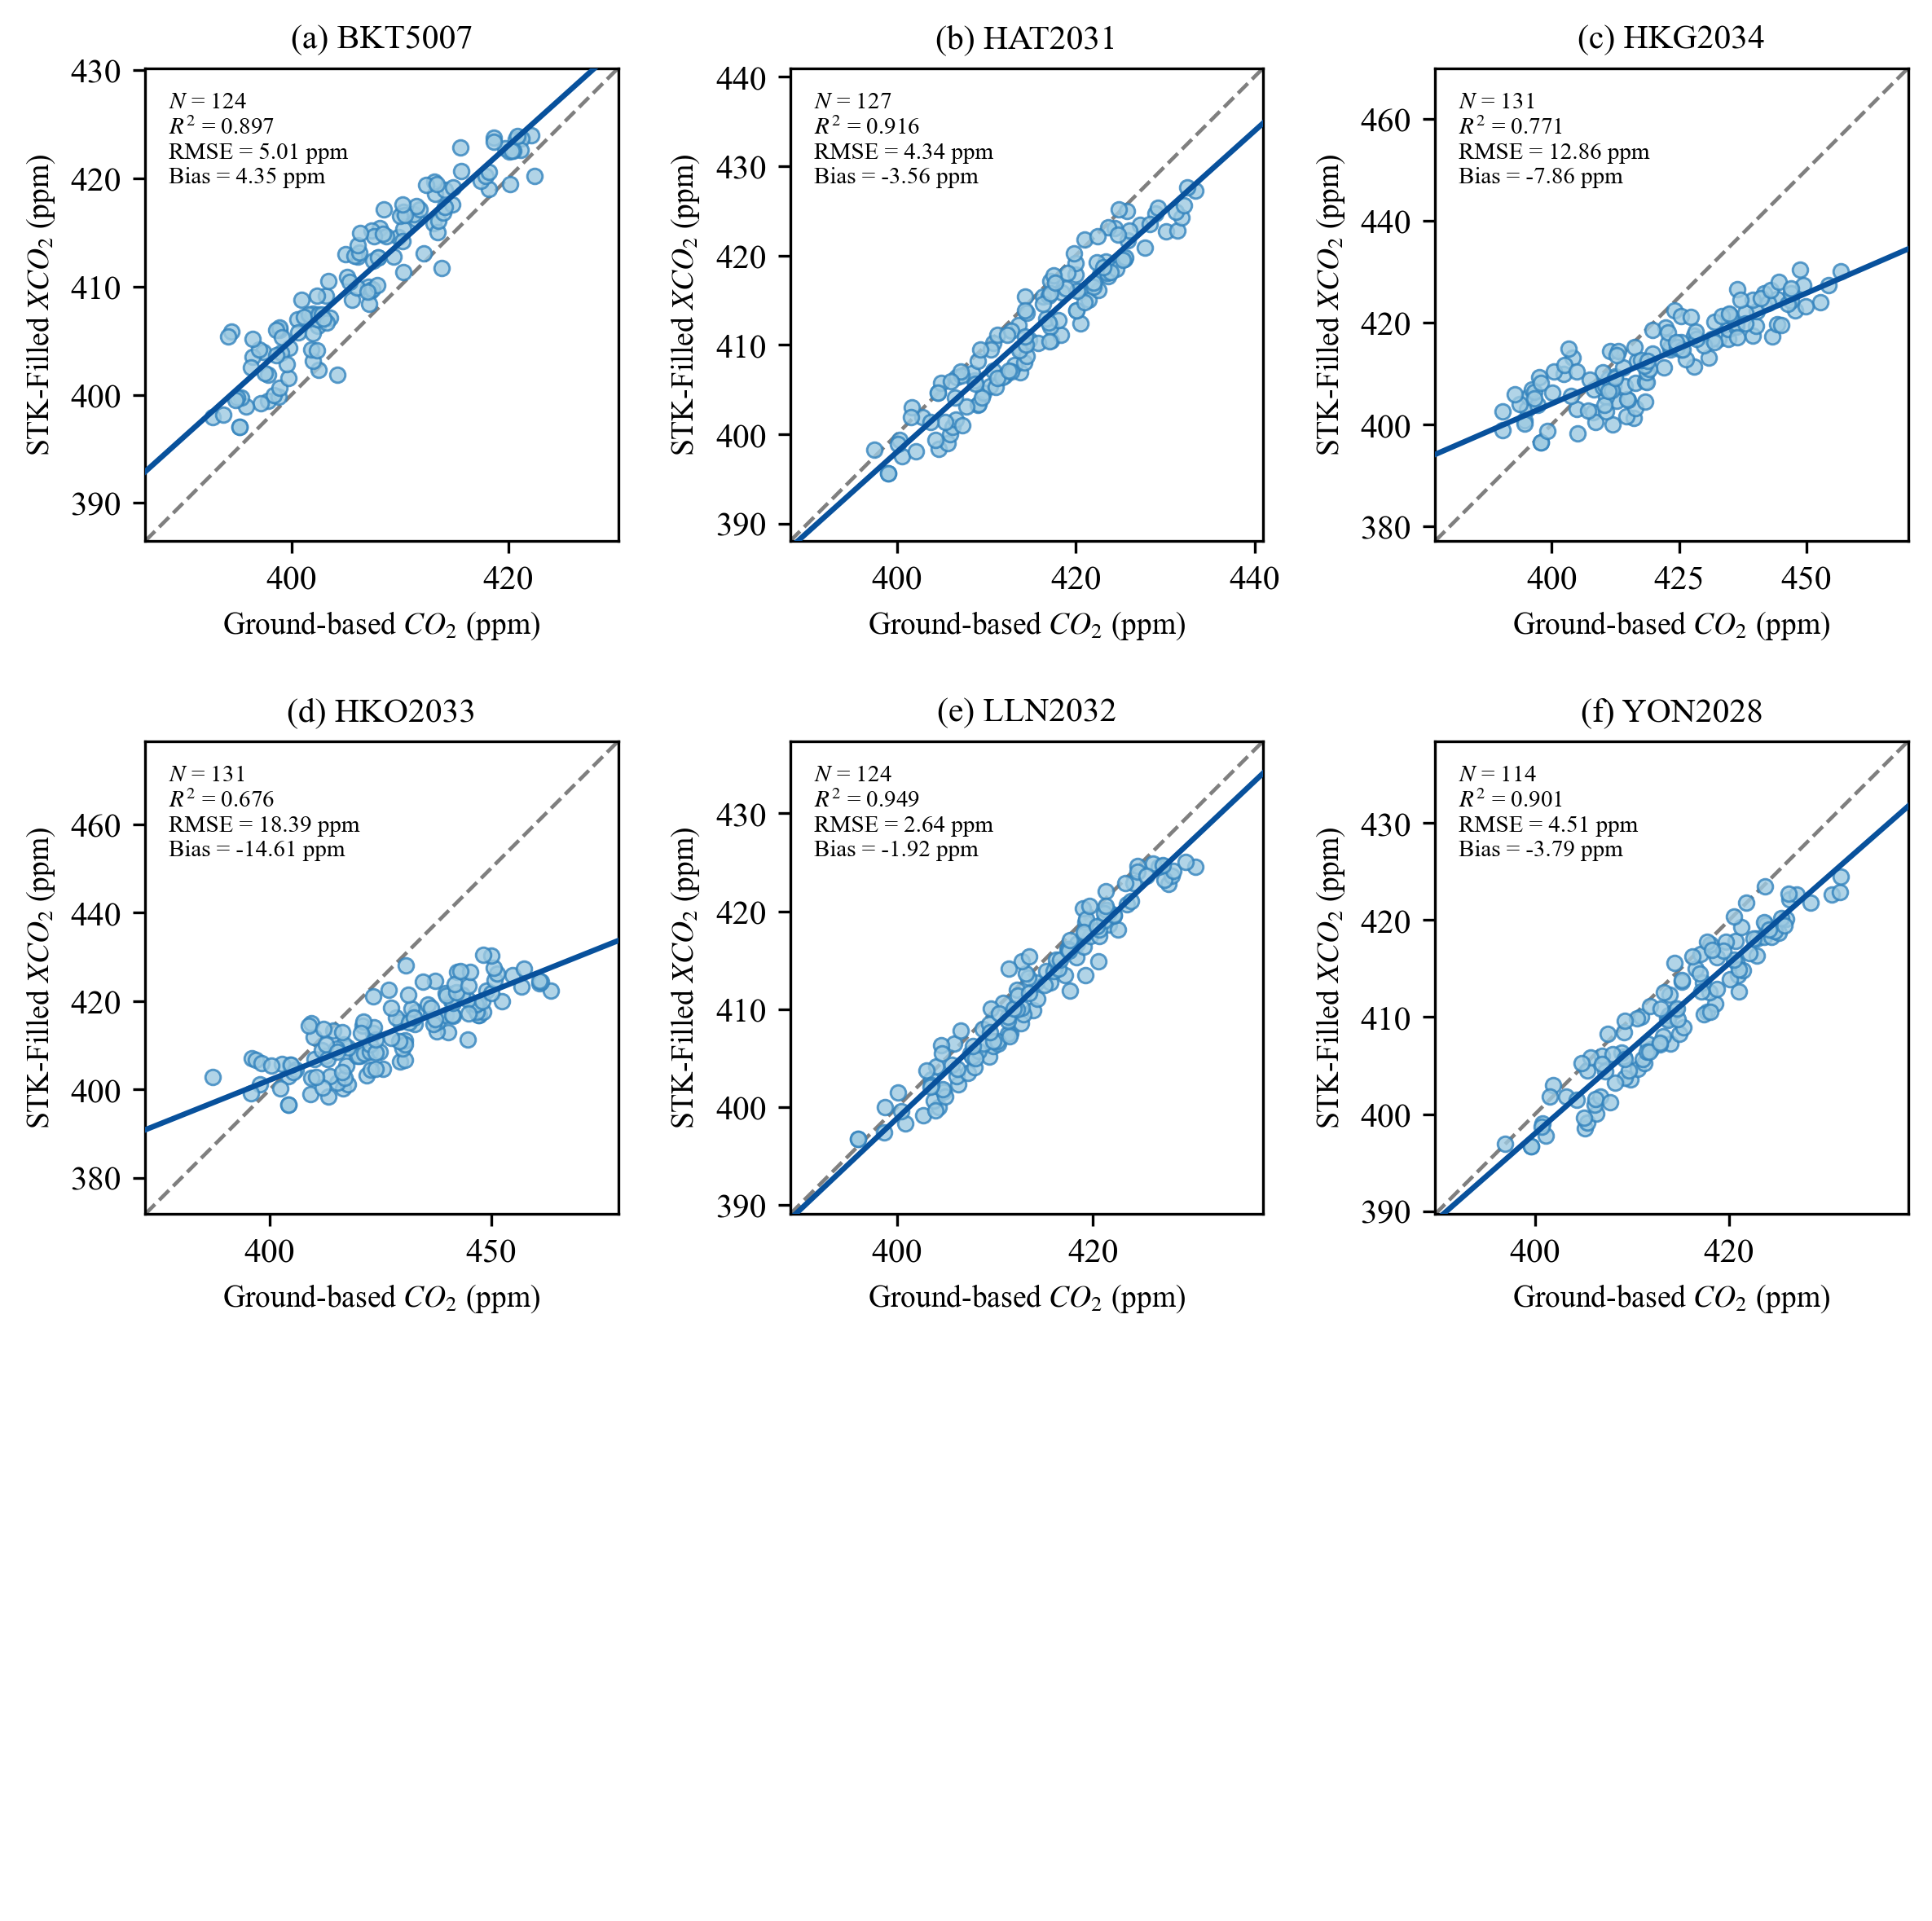

In [114]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import string
from pathlib import Path

# ==========================================
# 1. Configuration & Loading
# ==========================================

ground_obs = "WDCGG"
y_col = 'STK_XCO2'

# Set dynamic labels and column priorities based on the source
if ground_obs == "WDCGG":
    default_x_col = "CO2" # This matches the column name from our previous matching script
    x_label_text = "Ground-based $CO_2$ (ppm)"
else:
    default_x_col = "XCO2"
    x_label_text = "Ground-based $XCO_2$ (ppm)"

match_csv = Validation_DIR / f"Matched_stk_xco2_{ground_obs}.csv"
df_all = pd.read_csv(match_csv)

# ==========================================
# 2. Setup Figure
# ==========================================
fig, axes = plt.subplots(3, 3, figsize=(8, 8), dpi=300)
axes_flat = axes.flatten()

site_col = 'station' if 'station' in df_all.columns else 'site'
unique_sites = df_all[site_col].unique()

# ==========================================
# 3. Plotting Loop
# ==========================================
print(f"Generating validation plots for {len(unique_sites)} sites...")

# Track the last index used to hide remaining axes later
last_idx = -1

for i, site in enumerate(unique_sites):
    if i >= 9:
        break

    ax = axes_flat[i]
    last_idx = i

    # Filter data for the specific site
    df_site = df_all[df_all[site_col] == site].dropna(subset=[y_col])

    # Identify the actual ground-truth column present in this specific CSV
    # We use 'target_x' so we don't overwrite the global 'default_x_col'
    possible_cols = ['TCCON_XCO2_mean', 'Ground_CO2', 'co2', 'xco2', default_x_col]
    target_x = next((c for c in possible_cols if c in df_site.columns), None)

    if target_x is None:
        ax.text(0.5, 0.5, f"Column not found\nfor {site}", ha='center', transform=ax.transAxes)
        ax.set_title(f"({string.ascii_lowercase[i]}) {site}")
        continue

    # Call your professional plotting function
    plot_scatter(
        ax=ax,
        df=df_site,
        x_name=target_x,
        y_name=y_col,
        title_name=site,
        x_label=x_label_text,
        y_label="STK-Filled $XCO_2$ (ppm)",
        sublabel=string.ascii_lowercase[i],
        fontsize=10
    )

# ==========================================
# 4. Clean Up and Save
# ==========================================
# Hide unused subplots if sites < 9
for j in range(last_idx + 1, 9):
    axes_flat[j].axis('off')

plt.tight_layout()

output_fig = Validation_DIR / f"Validation_{ground_obs}.png"
plt.savefig(output_fig, bbox_inches='tight')
print(f"🚀 Success! Validation grid saved to: {output_fig}")
plt.show()

In [ ]:
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings

warnings.filterwarnings("ignore")
nc_dir=Path("/content/drive/MyDrive/xco2_datasets_conduct/co2_obs/TCCON")
Hf_path=nc_dir/"hf20151102_20241229.public.qc.nc"
Bu_path=nc_dir/"bu20151102_20241229.public.qc.nc"

stk_nc = "/content/drive/MyDrive/project_01_XCO2数据集构建/step04_stk_fill/oco2_xco2_month_2015_2024_stk_cn.nc"
tccon_file = "/content/drive/MyDrive/xco2_datasets_conduct/co2_obs/TCCON/hf20151102_20241229.public.qc.nc"

HEFEI_LAT = 31.926
HEFEI_LON = 117.165

ds_stk = xr.open_dataset(stk_nc)
stk_hefei = ds_stk['xco2'].sel(lat=HEFEI_LAT, lon=HEFEI_LON, method='nearest')

df_stk = stk_hefei.to_dataframe().reset_index()
df_stk = df_stk[['time', 'xco2']].rename(columns={'xco2': 'STK_XCO2'})
df_stk['time'] = pd.to_datetime(df_stk['time'])
df_stk.set_index('time', inplace=True)
df_stk.index = df_stk.index.to_period('M')

ds_tccon = xr.open_dataset(tccon_file)
tccon_time = ds_tccon['time'].values
tccon_xco2 = ds_tccon['xco2'].values

df_tccon_raw = pd.DataFrame({'time': tccon_time, 'TCCON_XCO2': tccon_xco2})
df_tccon_raw.set_index('time', inplace=True)
df_tccon_raw = df_tccon_raw.dropna()

df_tccon = df_tccon_raw.resample('ME').mean()
df_tccon.index = df_tccon.index.to_period('M')

df_matched = df_stk.join(df_tccon, how='inner').dropna()
df_matched.index = df_matched.index.to_timestamp()

stk_vals = df_matched['STK_XCO2'].values
tccon_vals = df_matched['TCCON_XCO2'].values

rmse = np.sqrt(mean_squared_error(tccon_vals, stk_vals))
mae = mean_absolute_error(tccon_vals, stk_vals)
mb = np.mean(stk_vals - tccon_vals)
slope, intercept, r_value, p_value, std_err = stats.linregress(tccon_vals, stk_vals)
r2 = r_value ** 2

print(f"R²   = {r2:.3f}")
print(f"RMSE = {rmse:.3f} ppm")
print(f"MAE  = {mae:.3f} ppm")
print(f"MB   = {mb:.3f} ppm")

fig = plt.figure(figsize=(16, 6))

ax1 = plt.subplot(1, 2, 1)
ax1.plot(df_matched.index, df_matched['TCCON_XCO2'], 'ko-', label='TCCON Ground Truth', alpha=0.7, markersize=6)
ax1.plot(df_matched.index, df_matched['STK_XCO2'], 'r*-', label='STK Interpolated (OCO-2)', linewidth=2, markersize=8)
ax1.set_title('(a) Monthly Time Series Comparison at Hefei Station', fontsize=15, fontweight='bold', pad=10)
ax1.set_ylabel('XCO2 Concentration (ppm)', fontsize=13)
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.legend(loc='upper left', fontsize=12)

ax2 = plt.subplot(1, 2, 2)
ax2.scatter(tccon_vals, stk_vals, c='tab:blue', alpha=0.7, edgecolors='white', s=60)
min_val = min(tccon_vals.min(), stk_vals.min()) - 1
max_val = max(tccon_vals.max(), stk_vals.max()) + 1
ax2.plot([min_val, max_val], [min_val, max_val], 'k--', linewidth=1.5, label='1:1 Reference Line')
fit_line = slope * np.array([min_val, max_val]) + intercept
ax2.plot([min_val, max_val], fit_line, 'r-', linewidth=2.5, label=f'Fit: y = {slope:.2f}x + {intercept:.2f}')
ax2.set_xlim([min_val, max_val])
ax2.set_ylim([min_val, max_val])
ax2.set_title('(b) Scatter Plot and Linear Regression', fontsize=15, fontweight='bold', pad=10)
ax2.set_xlabel('TCCON XCO2 (ppm)', fontsize=13)
ax2.set_ylabel('STK XCO2 (ppm)', fontsize=13)
ax2.grid(True, linestyle='--', alpha=0.5)
ax2.legend(loc='lower right', fontsize=12)

text_str = '\n'.join((
    f'N = {len(df_matched)} months',
    f'$R^2$ = {r2:.3f}',
    f'RMSE = {rmse:.2f} ppm',
    f'MAE = {mae:.2f} ppm',
    f'Bias = {mb:.2f} ppm'
))
props = dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='gray')
ax2.text(0.05, 0.95, text_str, transform=ax2.transAxes, fontsize=13, verticalalignment='top', bbox=props, family='monospace')

plt.tight_layout()
plt.show()
csn_fn="/content/drive/MyDrive/project_01_XCO2数据集构建/step05_Validation/tccon_hf_oco2.csv"
df_matched.to_csv(csn_fn)
print(csn_fn)

In [ ]:
import pandas as pd
import xarray as xr
import numpy as np

tccon_results = {}
fns = ["hf20151102_20241229.public.qc.nc", "bu20170303_20231228.public.qc.nc"]
site_names = ["Hefei", "Burgos"]

for i, fn in enumerate(fns):
    ds_tccon = xr.open_dataset(TCCON_PATH / fn, decode_times=True)

    df_tc_raw = pd.DataFrame({
        'time_utc': pd.to_datetime(ds_tccon['time'].values),
        'TCCON_XCO2': ds_tccon['xco2'].values
    }).dropna()

    df_tc_raw['time_local'] = df_tc_raw['time_utc'] + pd.Timedelta(hours=8)
    df_tc_raw['hour_local'] = df_tc_raw['time_local'].dt.hour

    df_tc_window = df_tc_raw[(df_tc_raw['hour_local'] >= 12) & (df_tc_raw['hour_local'] < 14)]

    df_tc_month = df_tc_window.set_index('time_utc').resample('MS').mean().reset_index()

    cols_to_drop = [c for c in ['hour_local', 'time_local'] if c in df_tc_month.columns]
    df_tc_month = df_tc_month.drop(columns=cols_to_drop)
    df_tc_month = df_tc_month.rename(columns={'time_utc': 'time'})

    site = site_names[i]
    tccon_results[site] = df_tc_month

for site, df in tccon_results.items():
    print(f"Site: {site} (Local Time 12-14h), Valid Months: {len(df)}")

In [ ]:
import math
import numpy as np
import matplotlib.pyplot as plt

sites_to_plot = ["Hefei", "Burgos"]
n_sites = len(sites_to_plot)
n_cols = 1
n_rows = math.ceil(n_sites / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(8/3, 2 * n_rows), dpi=300)
axes = np.atleast_1d(axes).flatten()

for i, site in enumerate(sites_to_plot):
    if site in tccon_results:
        df_site = tccon_results[site].sort_values("time")

        if not df_site.empty:
            plot_site_trend(axes[i], df_site.set_index("time"), site,"TCCON_XCO2", "XCO$_2$ (ppm)", 1, 1)
    else:
        axes[i].text(0.5, 0.5, f"{site} Data Missing", ha='center')

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
df_tc_raw

In [ ]:
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from scipy import stats
from sklearn.metrics import mean_squared_error
import math
from pathlib import Path
import warnings

warnings.filterwarnings("ignore")

PROJECT_DIR = Path("/content/drive/MyDrive/东南亚数据集")
xco2_fn = PROJECT_DIR / "step04_stk_fill/oco2_xco2_month_2014_2025_stk_cn.nc"
hour_csv_fn = PROJECT_DIR / "step01_Data/WGDCC/WGDCC站点co2_当地时12-14_月均值.csv"
month_csv_fn = PROJECT_DIR / "step01_Data/WGDCC/WGDCC站点co2逐月观测值.csv"

SITE_META = {
    'HAT': '海岛站 (Island)',
    'YON': '海岛站 (Island)',
    'BKT': '高山站 (Mountain)',
    'LLN': '高山站 (Mountain)',
    'HKG': '城市站 (City)',
    'HKO': '城市站 (City)'
}
sites_to_plot = ['HAT', 'YON']

def plot_scatter_2x(ax, df, x_name, y1_name, y2_name, title_name, sublabel="a"):
    data = df[[x_name, y1_name, y2_name]].dropna()
    x = data[x_name].values
    y1 = data[y1_name].values
    y2 = data[y2_name].values

    if len(x) < 2:
        ax.set_title(f"({sublabel}) {title_name} - 数据不足", fontproperties=prop_en)
        return

    slope1, intercept1, r1, p1, _ = stats.linregress(x, y1)
    rmse1 = np.sqrt(mean_squared_error(x, y1))

    slope2, intercept2, r2, p2, _ = stats.linregress(x, y2)
    rmse2 = np.sqrt(mean_squared_error(x, y2))

    color1 = "#1f77b4"
    color2 = "#d62728"

    ax.scatter(x, y2, s=40, facecolor="none", edgecolor=color2, linewidth=1.0,
               alpha=0.7, label="Monthly Mean", zorder=2)

    ax.scatter(x, y1, s=45, facecolor=color1, edgecolor="w", linewidth=0.5,
               alpha=0.85, label="Local 12-14h", zorder=3)

    all_val = np.concatenate([x, y1, y2])
    v_min, v_max = np.floor(all_val.min() - 1), np.ceil(all_val.max() + 1)
    ax.set_xlim([v_min, v_max])
    ax.set_ylim([v_min, v_max])
    ax.set_aspect('equal')

    xx = np.array([v_min, v_max])
    ax.plot(xx, xx, '--', lw=1.2, color="#7f7f7f", zorder=1)

    ax.plot(xx, slope1 * xx + intercept1, '-', lw=1.8, color=color1, zorder=4)
    ax.plot(xx, slope2 * xx + intercept2, ':', lw=1.5, color=color2, zorder=4)

    ax.set_title(f'({sublabel}) {title_name}', fontsize=12, fontweight='bold', fontproperties=prop_en)
    ax.set_xlabel(r'Satellite STK $XCO_2$ (ppm)', fontsize=10, fontproperties=prop_en)
    ax.set_ylabel(r'Ground Observed $CO_2$ (ppm)', fontsize=10, fontproperties=prop_en)

    stats_text = (
        f"$\mathbf{{Local\ 12-14h\ (Blue):}}$\n"
        f"$R^2$ = {r1**2:.3f}, RMSE = {rmse1:.2f}\n"
        f"$y$ = {slope1:.2f}$x$ + {intercept1:.2f}\n\n"
        f"$\mathbf{{Monthly\ Mean\ (Red):}}$\n"
        f"$R^2$ = {r2**2:.3f}, RMSE = {rmse2:.2f}\n"
        f"$y$ = {slope2:.2f}$x$ + {intercept2:.2f}"
    )

    ax.text(0.04, 0.96, stats_text, transform=ax.transAxes, fontsize=8, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='#bdbdbd'))

    ax.tick_params(axis='both', labelsize=9, direction='in', length=4, top=True, right=True)
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontproperties(prop_en)

    ax.legend(loc="lower right", fontsize=8, frameon=True, framealpha=0.7)

ds_sat = xr.open_dataset(xco2_fn)
if not np.issubdtype(ds_sat.time.dtype, np.datetime64): ds_sat = xr.decode_cf(ds_sat)
sat_var = 'xco2' if 'xco2' in ds_sat.data_vars else list(ds_sat.data_vars)[0]

df_h_all = pd.read_csv(hour_csv_fn)
df_m_all = pd.read_csv(month_csv_fn)

for df in [df_h_all, df_m_all]:
    df['time_period'] = pd.to_datetime(df['time']).dt.to_period('M')

n_sites = len(sites_to_plot)
fig, axes = plt.subplots(1, n_sites, figsize=(3 * n_sites, 3), dpi=300)
axes = np.atleast_1d(axes).flatten()

for i, site in enumerate(sites_to_plot):
    df_h = df_h_all[df_h_all['site'].str.contains(site, case=False)].copy()
    df_m = df_m_all[df_m_all['site'].str.contains(site, case=False)].copy()

    if df_h.empty or df_m.empty:
        continue

    lat, lon = df_h['lat'].iloc[0], df_h['lon'].iloc[0]

    ds_site = ds_sat[sat_var].sel(lat=lat, lon=lon, method='nearest')
    df_sat = ds_site.to_dataframe().reset_index()[['time', sat_var]].rename(columns={sat_var: 'sat_xco2'})
    df_sat['time_period'] = pd.to_datetime(df_sat['time']).dt.to_period('M')

    merged = pd.merge(df_sat, df_h[['time_period', 'co2_ppm']], on='time_period', how='inner')
    merged = pd.merge(merged, df_m[['time_period', 'co2_ppm']], on='time_period', suffixes=('_12h', '_month'))

    site_type = SITE_META.get(site, "监测站")
    full_title = f"站点: {site} ({site_type})"

    plot_scatter_2x(axes[i], merged, 'sat_xco2', 'co2_ppm_12h', 'co2_ppm_month', full_title, sublabel=chr(97+i))

plt.tight_layout()
plt.show()
ds_sat.close()

# TCCONT

# 重构数据验证：wdcgg

In [ ]:
# ==================================================
# 2. 数据准备与循环
# ==================================================
SITE_META = {'BKT': '高山站', 'HAT': '海岛站', 'YON': '海岛站', 'HKG': '城市站', 'HKO': '城市站', 'LLN': '高山站'}

SITE_META = {
    'BKT': 'Mountain Station',
    'HAT': 'Island Station',
    'YON': 'Island Station',
    'HKG': 'Urban Station',
    'HKO': 'Urban Station',
    'LLN': 'Mountain Station'
}
datetype = "month"
csv_fn = PROJECT_DIR / ("step01_Data/WGDCC/WGDCC站点co2逐月观测值.csv" if datetype == "month" else "...")
sites = ['BKT', 'HAT', 'HKG', 'HKO', 'LLN', 'YON']

ds_sat = xr.open_dataset("/content/drive/MyDrive/东南亚数据集/step04_stk_fill/oco2_xco2_month_2014_2025_stk_cn.nc")
df_obs = pd.read_csv(csv_fn, parse_dates=['time'])

n_cols = 3
n_rows = math.ceil(len(sites) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(7.5, 2.5 * n_rows), dpi=300)
axes = axes.flatten()

for i, site in enumerate(sites):
    site_data = df_obs[df_obs['site'].str.contains(site, case=False, na=False)].copy()
    if site_data.empty: continue

    lat, lon = site_data['lat'].iloc[0], site_data['lon'].iloc[0]

    try:
        # 卫星数据提取与匹配
        ds_site = ds_sat['xco2'].sel(lat=lat, lon=lon, method='nearest')
        df_sat_site = ds_site.to_dataframe().reset_index()[['time', 'xco2']].rename(columns={'xco2': 'sat_xco2'})

        site_data['time_period'] = site_data['time'].dt.to_period('M')
        df_sat_site['time_period'] = pd.to_datetime(df_sat_site['time']).dt.to_period('M')
        merged = pd.merge(site_data, df_sat_site, on='time_period', how='inner').dropna()

        # 站点信息
        clean_id = "".join([c for c in site if c.isalpha()])
        full_title = f"{clean_id} ({SITE_META.get(clean_id, '监测站')})"

        plot_scatter(axes[i], merged, 'co2_ppm', 'sat_xco2',
                     title_name=full_title,
                     x_label='WDCGG $CO_2$ (ppm)',
                     y_label='STK $XCO_2$ (ppm)',
                     sublabel=chr(97+i))

    except Exception as e:
        axes[i].set_title(f"({chr(97+i)}) {site} 匹配失败", fontproperties=prop_cn, fontsize=10)

# 清理多余子图
for j in range(i + 1, len(axes)): axes[j].axis('off')

plt.tight_layout()
plt.show()
ds_sat.close()

In [ ]:
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.font_manager as fm
import math
import numpy as np
from pathlib import Path

# ==================================================
def plot_time_series(ax, df, x_col, y1_col, y2_col, title_name, y_label, sublabel):
    """
    绘制地基与卫星对比折线图，并在右下角标注相关系数 R
    """
    plot_df = df.copy()

    # ---- 时间列处理 ----
    if pd.api.types.is_period_dtype(plot_df[x_col]):
        plot_df[x_col] = plot_df[x_col].dt.to_timestamp()
    else:
        plot_df[x_col] = pd.to_datetime(plot_df[x_col])

    # ---- 排序与去空 ----
    plot_df = plot_df[[x_col, y1_col, y2_col]].dropna().sort_values(x_col)

    if plot_df.empty:
        ax.text(0.5, 0.5, "No matched data", transform=ax.transAxes, ha='center', va='center')
        return None

    # ==== 计算相关系数 R ====
    r_value = plot_df[y1_col].corr(plot_df[y2_col])
    r_text = f'$R$ = {r_value:.2f}' if not np.isnan(r_value) else '$R$ = N/A'

    # ---- 绘制折线 ----
    # WDCGG 地面观测 (红实线)
    l1, = ax.plot(plot_df[x_col], plot_df[y1_col], label='WDCGG CO$_2$',
                  color='#d62728', marker='o', markersize=1.2, linewidth=0.5, alpha=0.8)

    # STK 卫星填补 (蓝虚线)
    l2, = ax.plot(plot_df[x_col], plot_df[y2_col], label='STK XCO$_2$',
                  color='#1f77b4', linestyle='--', marker='s', markersize=1.2, linewidth=0.5, alpha=0.8)

    # ---- 标注相关系数 R (右下角) ----
    ax.text(0.96, 0.06, r_text, transform=ax.transAxes, ha='right', va='bottom',
            fontsize=9, fontweight='bold', fontproperties=prop_en,
            bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', pad=1))

    # ---- 标题与子图编号 ----
    ax.set_title(f"({sublabel}) {title_name}", loc='left', fontproperties=prop_en, pad=6)
    ax.set_ylabel(y_label, fontproperties=prop_en)

    # ---- X轴时间格式精调 ----
    ax.xaxis.set_major_locator(mdates.YearLocator(base=2)) # 每2年显示一个标签
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_minor_locator(mdates.YearLocator())


    for t in ax.get_xticklabels() + ax.get_yticklabels():
        t.set_fontproperties(prop_en)
        t.set_fontsize(9)

    for spine in ax.spines.values():
        spine.set_linewidth(0.8)

    return l1, l2

# ==================================================
# 2. 数据加载与预处理
# ==================================================
SITE_META = {
    'BKT': 'Mountain Station', 'HAT': 'Island Station', 'YON': 'Island Station',
    'HKG': 'Urban Station',    'HKO': 'Urban Station',  'LLN': 'Mountain Station'
}

# 路径设置
csv_fn = PROJECT_DIR / "step01_Data/WGDCC/WGDCC站点co2逐月观测值.csv"
sat_nc = "/content/drive/MyDrive/东南亚数据集/step04_stk_fill/oco2_xco2_month_2014_2025_stk_cn.nc"

df_obs = pd.read_csv(csv_fn, parse_dates=['time'])
ds_sat = xr.open_dataset(sat_nc)
sites = ['BKT', 'HAT', 'HKG', 'HKO', 'LLN', 'YON']

# 存储预处理后的绘图信息
plot_info = []
for site in sites:
    # 提取地面站点数据
    site_data = df_obs[df_obs['site'].str.contains(site, case=False, na=False)].copy()
    if site_data.empty: continue

    lat, lon = site_data['lat'].iloc[0], site_data['lon'].iloc[0]

    try:
        # 提取对应经纬度的卫星数据
        ds_site = ds_sat['xco2'].sel(lat=lat, lon=lon, method='nearest')
        df_sat_site = ds_site.to_dataframe().reset_index()[['time', 'xco2']].rename(columns={'xco2': 'sat_xco2'})

        # 时间对齐 (Period 匹配)
        site_data['time_period'] = site_data['time'].dt.to_period('M')
        df_sat_site['time_period'] = pd.to_datetime(df_sat_site['time']).dt.to_period('M')

        merged = pd.merge(site_data, df_sat_site, on='time_period', how='inner').sort_values('time_period')
        merged = merged[['time_period', 'co2_ppm', 'sat_xco2']].dropna()

        # 生成标题
        clean_id = "".join([c for c in site if c.isalpha()]).upper()
        full_title = f"{clean_id} ({SITE_META.get(clean_id, 'Ground Station')})"

        plot_info.append((merged, full_title))
    except Exception as e:
        print(f"Station {site} error: {e}")

# ==================================================
# 3. 绘图循环
# ==================================================
n_cols = 3
n_rows = math.ceil(len(plot_info) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(8, 2. * n_rows), dpi=300, sharey=False)
axes = axes.flatten()

legend_handles = None

for i, (merged, full_title) in enumerate(plot_info):
    ax = axes[i]

    # 调用绘图函数
    res = plot_time_series(
        ax=ax,
        df=merged,
        x_col='time_period',
        y1_col='co2_ppm',
        y2_col='sat_xco2',
        title_name=full_title,
        y_label='CO$_2$ / XCO$_2$ (ppm)',
        sublabel=chr(97 + i)
    )

    if res and legend_handles is None:
        legend_handles = res

    # 仅在最后一行显示 X 轴标签 "Year"
    if (i // n_cols) == (n_rows - 1):
        ax.set_xlabel('Year', fontproperties=prop_en)

# 移除多余的空白子图
for j in range(len(plot_info), len(axes)):
    axes[j].axis('off')

# ---- 顶部中央总图例 ----
if legend_handles:
    fig.legend(
        legend_handles, ['WDCGG CO$_2$', 'STK XCO$_2$'],
        loc='upper center', ncol=2, frameon=False,
        bbox_to_anchor=(0.5, 1.02), prop=prop_en
    )

plt.tight_layout(rect=[0, 0, 1, 0.96]) # 为顶部图例留出空间
plt.show()

ds_sat.close()

#重建数据验证： oco3数据

In [ ]:
import xarray as xr
import numpy as np
import pandas as pd
PROJECT_DIR=Path("/content/drive/MyDrive/东南亚数据集/")
obs_nc= PROJECT_DIR / "step03_谐波订正/oco3_xco2_month_201908_202512.nc"
stk_nc= PROJECT_DIR / "step04_stk_fill/oco2_xco2_month_2014_2025_stk_cn.nc"

ds_stk = xr.open_dataset(stk_nc)
obs_ds = xr.open_dataset(obs_nc)

da_stk = ds_stk["xco2"]
da_obs = obs_ds["xco2"]

csn_fn= PROJECT_DIR /"step05_Validation/重建数据_OCO3验证.csv"

da_stk = da_stk.sel(time=~da_stk.get_index("time").duplicated())
da_obs = da_obs.sel(time=~da_obs.get_index("time").duplicated())

if not (da_stk.lat.equals(da_obs.lat) and da_stk.lon.equals(da_obs.lon)):
    print("正在进行空间坐标对齐（插值）...")
    da_stk = da_stk.interp_like(da_obs, method="nearest")

common_time = np.intersect1d(da_stk.time.values, da_obs.time.values)
da_stk_c = da_stk.sel(time=common_time)
da_obs_c = da_obs.sel(time=common_time)


mask = da_stk_c.notnull() & da_obs_c.notnull()

ds_combined = xr.Dataset({
    'stk_xco2': da_stk_c,
    'obs_xco2': da_obs_c
})

df_match = ds_combined.where(mask, drop=True).to_dataframe().dropna().reset_index()

print(f"验证完成：在重叠的时空范围内共提取到 {len(df_match)} 个有效匹配样本。")
df_match.to_csv(csn_fn, index=False)
print(f"结果已保存至: {csn_fn}")

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable


df = pd.read_csv(csv_out)
fig, ax = plt.subplots(figsize=(3, 3),dpi=300)

sc, use_density = plot_density_scatter(
    ax=ax,
    df=df,
    y_name="stk_xco2",  # 对应之前的 ds_stk (OCO-2)
    x_name="obs_xco2",  # 对应之前的 ds_obs (OCO-3)
    title_name="",
    y_label="STK XCO$_2$ (ppm)",
    x_label="OCO-3 XCO$_2$ (ppm)",
    sublabel="(a)",      # 这里的 sublabel 通常是图左上角的编号
    fontsize=10
)

if use_density and sc is not None:
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="4%", pad=0.1)
    cbar = fig.colorbar(sc, cax=cax)
    cbar.set_label("密度", fontsize=9, fontproperties=prop_cn)
    cbar.ax.tick_params(labelsize=8)
    if 'prop_en' in locals() and prop_en:
        p_en = prop_en.copy()
        p_en.set_size(8)
        for t in cbar.ax.get_yticklabels():
            t.set_fontproperties(p_en)

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error

# --- 1. 数据准备 ---
df = pd.read_csv(csv_out)
df['time'] = pd.to_datetime(df['time'])
df['month'] = df['time'].dt.month

df['error'] = df['stk_xco2'] - df['obs_xco2']

# --- 2. 计算全局误差指标 ---
bias = df['error'].mean()
rmse = np.sqrt(mean_squared_error(df['stk_xco2'], df['obs_xco2']))
mae = mean_absolute_error(df['stk_xco2'], df['obs_xco2'])
r = df['stk_xco2'].corr(df['obs_xco2'])

print(f"误差统计结果：")
print(f"  - 平均偏差 (Bias): {bias:.4f} ppm")
print(f"  - 均方根误差 (RMSE): {rmse:.4f} ppm")
print(f"  - 平均绝对误差 (MAE): {mae:.4f} ppm")
print(f"  - 相关系数 (R): {r:.4f}")

# --- 3. 绘制月度小提琴图 ---
fig, ax = plt.subplots(figsize=(6, 4))

# 使用 seaborn 绘制小提琴图
sns.violinplot(data=df, x='month', y='error', ax=ax,
               palette="RdYlBu_r", inner="quartile", linewidth=1.2)

# 添加 0 误差基准线
ax.axhline(0, color='red', linestyle='--', lw=1, alpha=0.7)

# 图表装饰
ax.set_title("OCO-2 vs OCO-3 误差月度分布特征", fontproperties=prop_cn, fontsize=14, fontweight="bold")
ax.set_xlabel("月份", fontproperties=prop_cn, fontsize=12)
ax.set_ylabel("Error (STK - OBS) [ppm]", fontproperties=prop_en, fontsize=12)

# 设置坐标轴字体
for t in ax.get_xticklabels() + ax.get_yticklabels():
    t.set_fontproperties(prop_en)

plt.grid(axis='y', linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

In [ ]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
import matplotlib.pyplot as plt
import numpy as np

# --- 1. 数据预处理 ---
# 确保 df 中有 month 列
if 'month' not in df.columns:
    df['month'] = pd.to_datetime(df['time']).dt.month

spatial_monthly_error = df.groupby(['month', 'lat', 'lon'])['error'].mean().reset_index()

# --- 2. 绘图参数设置 ---
EXTENT = [92, 143, -10, 32]
v_lim = 5.0
rows, cols = 3, 4
fig = plt.figure(figsize=(10, 2.5*3))

# 遍历 1-12 月
for m in range(1, 13):
    # 创建子图
    ax = fig.add_subplot(rows, cols, m, projection=ccrs.PlateCarree())

    # 提取当月数据
    m_data = spatial_monthly_error[spatial_monthly_error['month'] == m]

    # 绘制散点/网格误差图
    sc = ax.scatter(m_data['lon'], m_data['lat'],
                    c=m_data['error'], s=8,
                    cmap='RdBu_r', vmin=-v_lim, vmax=v_lim,
                    edgecolors='none', marker='s',
                    transform=ccrs.PlateCarree())

    # 地图修饰
    ax.add_feature(cfeature.COASTLINE, lw=0.4)
    ax.add_feature(cfeature.BORDERS, lw=0.3, ls=':')
    ax.add_feature(cfeature.OCEAN, facecolor='#f9f9f9')

    # 设置范围
    ax.set_extent(EXTENT, crs=ccrs.PlateCarree())

    # 标题
    ax.set_title(f"{m}月", fontproperties=prop_cn, fontsize=14, fontweight="bold")

    # 坐标轴控制：只在左侧和底部显示标签以节省空间
    ax.set_xticks(np.arange(100, 141, 20), crs=ccrs.PlateCarree())
    ax.set_yticks(np.arange(-10, 31, 10), crs=ccrs.PlateCarree())
    ax.xaxis.set_major_formatter(LongitudeFormatter())
    ax.yaxis.set_major_formatter(LatitudeFormatter())

    # 精简标签：非第一列隐藏Y轴，非最后一行隐藏X轴
    if (m - 1) % cols != 0:
        ax.tick_params(axis='y', labelleft=False)
    if m <= 8:
        ax.tick_params(axis='x', labelbottom=False)

    for t in ax.get_xticklabels() + ax.get_yticklabels():
        t.set_fontproperties(prop_en)
        t.set_size(10)


fig.subplots_adjust(bottom=0.12, top=0.92, left=0.05, right=0.95, wspace=0.1, hspace=0.2)

# 创建色标坐标轴 [左, 下, 宽, 高]
cbar_ax = fig.add_axes([0.3, 0.06, 0.4, 0.02])
cbar = fig.colorbar(sc, cax=cbar_ax, orientation='horizontal', extend='both')
cbar.set_label("Bias (ppm)", fontproperties=prop_en, fontsize=12)

for t in cbar.ax.get_xticklabels():
    t.set_fontproperties(prop_en)

plt.show()

# 重建数据集的时空分布

In [ ]:
import math
import shutil
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib.dates as mdates
from mpl_toolkits.axes_grid1 import make_axes_locatable
from scipy.stats import linregress
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter

warnings.filterwarnings("ignore")

def setup_fonts():
    font_map = {
        "Times.ttf": "/content/drive/MyDrive/fonts/TimesNewRoman.ttf",
        "SimSun.ttf": "/content/drive/MyDrive/fonts/SimSun.ttf"
    }
    props = {"en": None, "cn": None}
    for name, drive_p in font_map.items():
        local_p = Path(f"/content/{name}")
        if Path(drive_p).exists():
            if not local_p.exists(): shutil.copy(drive_p, local_p)
            fm.fontManager.addfont(str(local_p))
            if "Times" in name: props["en"] = fm.FontProperties(fname=str(local_p))
            else: props["cn"] = fm.FontProperties(fname=str(local_p))
    plt.rcParams.update({
        "font.family": "serif", "font.serif": ["Times New Roman", "SimSun"],
        "mathtext.fontset": "stix", "axes.unicode_minus": False, "font.size": 10
    })
    return props["en"], props["cn"]

prop_en, prop_cn = setup_fonts()

stk_nc = "/content/drive/MyDrive/东南亚数据集/step04_stk_fill/oco2_xco2_month_2014_2025_stk_cn.nc"
ds = xr.open_dataset(stk_nc)
var_name = "xco2" if "xco2" in ds.data_vars else list(ds.data_vars)[0]
da = ds[var_name]
da = ds[var_name].sel(time=slice("2015", "2024"))
if "time" not in da.dims:
    da = da.rename({[d for d in da.dims if d in ["month", "date"]][0]: "time"})
if "lat" not in da.dims:
    da = da.rename({[d for d in da.dims if d in ["latitude", "y"]][0]: "lat"})
if "lon" not in da.dims:
    da = da.rename({[d for d in da.dims if d in ["longitude", "x"]][0]: "lon"})

if not np.issubdtype(da["time"].dtype, np.datetime64):
    da["time"] = xr.decode_cf(ds).time

ts = da.mean(dim=["lat", "lon"], skipna=True)
years = da["time"].dt.year + (da["time"].dt.month - 1) / 12.0
t_num = years.values
mask_ts = np.isfinite(ts.values)
slope_ts, inter_ts, r_ts, _, _ = linregress(t_num[mask_ts], ts.values[mask_ts])
trend_line = inter_ts + slope_ts * t_num

mean_map = da.mean(dim="time", skipna=True)

def calc_trend(y):
    idx = np.isfinite(y)
    if np.sum(idx) < 10: return np.nan
    return linregress(t_num[idx], y[idx])[0]

trend_map = xr.apply_ufunc(calc_trend, da, input_core_dims=[["time"]], vectorize=True, dask="parallelized", output_dtypes=[float])

In [ ]:
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(10.5, 2.5), dpi=300)
gs = gridspec.GridSpec(
    1, 5,
    width_ratios=[1, 0.15, 1, 0.3, 1],  # 子图1-2间距=0.2，子图2-3间距=0.4
    wspace=0.0
)
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 2], projection=ccrs.PlateCarree())
ax3 = fig.add_subplot(gs[0, 4], projection=ccrs.PlateCarree())

EXTENT = [92, 143, -10, 32]

ax1.plot(da["time"].values, ts.values, color="#2166ac", lw=0.75, marker="o", ms=1, label="月均值")
ax1.plot(da["time"].values, trend_line, color="#d62728", ls="--", lw=1.5, label=f"趋势: {slope_ts:.2f} ppm/yr")
y_min, y_max = np.nanmin(ts.values), np.nanmax(ts.values)
y_range = y_max - y_min
ax1.set_ylim(y_min - 0.05 * y_range, y_max + 0.2 * y_range)
ax1.set_box_aspect(0.75)

ax1.xaxis.set_major_locator(mdates.YearLocator(2))
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax1.set_ylabel("XCO$_2$ (ppm)", fontproperties=prop_en)
ax1.set_title("(a) 区域均值时间变化", fontproperties=prop_cn, fontweight="bold")

ax1.legend(loc="upper left", frameon=False, prop=prop_cn, fontsize=7)
for t in ax1.get_xticklabels() + ax1.get_yticklabels(): t.set_fontproperties(prop_en)


vmin, vmax = np.nanpercentile(mean_map, [0.5, 99.5])
im1 = ax2.pcolormesh(da.lon, da.lat, mean_map, cmap="RdYlBu_r", shading="auto", vmin=vmin, vmax=vmax, transform=ccrs.PlateCarree())
ax2.add_feature(cfeature.COASTLINE, lw=0.4)
ax2.add_feature(cfeature.BORDERS, lw=0.4)
ax2.set_title("(b) 多年平均", fontproperties=prop_cn, fontweight="bold")
ax2.set_xticks(np.arange(da.lon.min(), da.lon.max()+1, 10), crs=ccrs.PlateCarree())
ax2.set_yticks(np.arange(da.lat.min(), da.lat.max()+1, 10), crs=ccrs.PlateCarree())
ax2.xaxis.set_major_formatter(LongitudeFormatter())
ax2.yaxis.set_major_formatter(LatitudeFormatter())
ax2.set_extent(EXTENT, crs=ccrs.PlateCarree())
add_scalebar(ax2)
add_north_arrow(ax2)
for t in ax2.get_xticklabels() + ax2.get_yticklabels(): t.set_fontproperties(prop_en)

divider2 = make_axes_locatable(ax2)
cax2 = divider2.append_axes("right", size="3%", pad=0.1, axes_class=plt.Axes)
cb2 = plt.colorbar(im1, cax=cax2, orientation="vertical", extend='both')
cb2.set_label("ppm", fontproperties=prop_en)
for t in cb2.ax.get_yticklabels(): t.set_fontproperties(prop_en)

vmin, vmax = np.nanpercentile(trend_map, [0.5, 99.5])
im2 = ax3.pcolormesh(da.lon, da.lat, trend_map, cmap="RdYlBu_r", shading="auto", vmin=vmin, vmax=vmax, transform=ccrs.PlateCarree())
ax3.add_feature(cfeature.COASTLINE, lw=0.4)
ax3.add_feature(cfeature.BORDERS, lw=0.4)
ax3.set_title("(c) 线性趋势变化率", fontproperties=prop_cn, fontweight="bold")
ax3.set_xticks(np.arange(da.lon.min(), da.lon.max()+1, 10), crs=ccrs.PlateCarree())
ax3.set_yticks(np.arange(da.lat.min(), da.lat.max()+1, 10), crs=ccrs.PlateCarree())
ax3.xaxis.set_major_formatter(LongitudeFormatter())
ax3.yaxis.set_major_formatter(LatitudeFormatter())
ax3.set_extent(EXTENT, crs=ccrs.PlateCarree())
add_scalebar(ax2)
add_north_arrow(ax3)
for t in ax3.get_xticklabels() + ax3.get_yticklabels(): t.set_fontproperties(prop_en)

divider3 = make_axes_locatable(ax3)
cax3 = divider3.append_axes("right", size="3%", pad=0.1, axes_class=plt.Axes)
cb3 = plt.colorbar(im2, cax=cax3, orientation="vertical", extend='both')
cb3.set_label("ppm yr$^{-1}$", fontproperties=prop_en)
for t in cb3.ax.get_yticklabels(): t.set_fontproperties(prop_en)

plt.tight_layout()

plt.show()
ds.close()

# 交叉验证： oco2 vs oco3数据

In [117]:
#时空匹配 OCO2_STK
import xarray as xr
import numpy as np
import pandas as pd

obs_nc= PROJECT_DIR / "step03_Keeling_curve/oco3_xco2_month_201908_202512.nc"
stk_nc= PROJECT_DIR / "step04_stk_fill/oco2_xco2_month_2014_2014_stk_SEA.nc"

ds_stk = xr.open_dataset(stk_nc)
obs_ds = xr.open_dataset(obs_nc)

da_stk = ds_stk["xco2"]
da_obs = obs_ds["xco2"]

csn_fn= PROJECT_DIR /"step05_Validation/Matched_stk_oco3.csv"

da_stk = da_stk.sel(time=~da_stk.get_index("time").duplicated())
da_obs = da_obs.sel(time=~da_obs.get_index("time").duplicated())

if not (da_stk.lat.equals(da_obs.lat) and da_stk.lon.equals(da_obs.lon)):
    print("正在进行空间坐标对齐（插值）...")
    da_stk = da_stk.interp_like(da_obs, method="nearest")

common_time = np.intersect1d(da_stk.time.values, da_obs.time.values)
da_stk_c = da_stk.sel(time=common_time)
da_obs_c = da_obs.sel(time=common_time)


mask = da_stk_c.notnull() & da_obs_c.notnull()

ds_combined = xr.Dataset({
    'stk_xco2': da_stk_c,
    'oco3': da_obs_c
})

df_match = ds_combined.where(mask, drop=True).to_dataframe().dropna().reset_index()


print(f"验证完成：在重叠的时空范围内共提取到 {len(df_match)} 个有效匹配样本。")
df_match.to_csv(csn_fn, index=False)
print(f"结果已保存至: {csn_fn}")

验证完成：在重叠的时空范围内共提取到 1040563 个有效匹配样本。
结果已保存至: /content/drive/MyDrive/Southeast_Asia_XCO2_STK/step05_Validation/Matched_stk_oco3.csv


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

csn_fn= PROJECT_DIR /"step05_Validation/重建数据验证_oco3数据.csv"
df = pd.read_csv(csn_fn)
fig, ax = plt.subplots(figsize=(3, 3),dpi=300)

sc, use_density = plot_density_scatter(
    ax=ax,
    df=df,
    y_name="stk_xco2",  # 对应之前的 ds_stk (OCO-2)
    x_name="obs_xco2",  # 对应之前的 ds_obs (OCO-3)
    title_name="",
    y_label="STK XCO$_2$ (ppm)",
    x_label="OCO-3 XCO$_2$ (ppm)",
    sublabel="(a)",      # 这里的 sublabel 通常是图左上角的编号
    fontsize=10
)

if use_density and sc is not None:
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="4%", pad=0.1)
    cbar = fig.colorbar(sc, cax=cax)
    cbar.set_label("密度", fontsize=9, fontproperties=prop_cn)
    cbar.ax.tick_params(labelsize=8)
    if 'prop_en' in locals() and prop_en:
        p_en = prop_en.copy()
        p_en.set_size(8)
        for t in cbar.ax.get_yticklabels():
            t.set_fontproperties(p_en)

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error

# --- 1. 数据准备 ---
df = pd.read_csv(csv_out)
df['time'] = pd.to_datetime(df['time'])
df['month'] = df['time'].dt.month

df['error'] = df['stk_xco2'] - df['obs_xco2']

# --- 2. 计算全局误差指标 ---
bias = df['error'].mean()
rmse = np.sqrt(mean_squared_error(df['stk_xco2'], df['obs_xco2']))
mae = mean_absolute_error(df['stk_xco2'], df['obs_xco2'])
r = df['stk_xco2'].corr(df['obs_xco2'])

print(f"误差统计结果：")
print(f"  - 平均偏差 (Bias): {bias:.4f} ppm")
print(f"  - 均方根误差 (RMSE): {rmse:.4f} ppm")
print(f"  - 平均绝对误差 (MAE): {mae:.4f} ppm")
print(f"  - 相关系数 (R): {r:.4f}")

# --- 3. 绘制月度小提琴图 ---
fig, ax = plt.subplots(figsize=(6, 4))

# 使用 seaborn 绘制小提琴图
sns.violinplot(data=df, x='month', y='error', ax=ax,
               palette="RdYlBu_r", inner="quartile", linewidth=1.2)

# 添加 0 误差基准线
ax.axhline(0, color='red', linestyle='--', lw=1, alpha=0.7)

# 图表装饰
ax.set_title("OCO-2 vs OCO-3 误差月度分布特征", fontproperties=prop_cn, fontsize=14, fontweight="bold")
ax.set_xlabel("月份", fontproperties=prop_cn, fontsize=12)
ax.set_ylabel("Error (STK - OBS) [ppm]", fontproperties=prop_en, fontsize=12)

# 设置坐标轴字体
for t in ax.get_xticklabels() + ax.get_yticklabels():
    t.set_fontproperties(prop_en)

plt.grid(axis='y', linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

In [ ]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
import matplotlib.pyplot as plt
import numpy as np

# --- 1. 数据预处理 ---
# 确保 df 中有 month 列
if 'month' not in df.columns:
    df['month'] = pd.to_datetime(df['time']).dt.month

# 计算各月、各格点的多年平均误差
# 如果数据量极大，建议先 groupby 再绘图
spatial_monthly_error = df.groupby(['month', 'lat', 'lon'])['error'].mean().reset_index()

# --- 2. 绘图参数设置 ---
EXTENT = [92, 143, -10, 32]
v_lim = 3.0  # 偏差显示范围 [-5.0, 5.0]
rows, cols = 3, 4
fig = plt.figure(figsize=(20, 12))

# 遍历 1-12 月
for m in range(1, 13):
    # 创建子图
    ax = fig.add_subplot(rows, cols, m, projection=ccrs.PlateCarree())

    # 提取当月数据
    m_data = spatial_monthly_error[spatial_monthly_error['month'] == m]

    # 绘制散点/网格误差图
    sc = ax.scatter(m_data['lon'], m_data['lat'],
                    c=m_data['error'], s=8,
                    cmap='PiYG', vmin=-v_lim, vmax=v_lim,
                    edgecolors='none', marker='s',
                    transform=ccrs.PlateCarree())

    # 地图修饰
    ax.add_feature(cfeature.COASTLINE, lw=0.4)
    ax.add_feature(cfeature.BORDERS, lw=0.3, ls=':')
    ax.add_feature(cfeature.OCEAN, facecolor='#f9f9f9')

    # 设置范围
    ax.set_extent(EXTENT, crs=ccrs.PlateCarree())

    # 标题
    ax.set_title(f"{m}月", fontproperties=prop_cn, fontsize=14, fontweight="bold")

    # 坐标轴控制：只在左侧和底部显示标签以节省空间
    ax.set_xticks(np.arange(100, 141, 20), crs=ccrs.PlateCarree())
    ax.set_yticks(np.arange(-10, 31, 10), crs=ccrs.PlateCarree())
    ax.xaxis.set_major_formatter(LongitudeFormatter())
    ax.yaxis.set_major_formatter(LatitudeFormatter())

    # 精简标签：非第一列隐藏Y轴，非最后一行隐藏X轴
    if (m - 1) % cols != 0:
        ax.tick_params(axis='y', labelleft=False)
    if m <= 8:
        ax.tick_params(axis='x', labelbottom=False)

    for t in ax.get_xticklabels() + ax.get_yticklabels():
        t.set_fontproperties(prop_en)
        t.set_size(10)

# --- 3. 添加全局色标 ---
# subplots_adjust 为底部留出空间 [left, bottom, right, top]
fig.subplots_adjust(bottom=0.12, top=0.92, left=0.05, right=0.95, wspace=0.1, hspace=0.2)

# 创建色标坐标轴 [左, 下, 宽, 高]
cbar_ax = fig.add_axes([0.3, 0.06, 0.4, 0.02])
cbar = fig.colorbar(sc, cax=cbar_ax, orientation='horizontal', extend='both')
cbar.set_label("Bias (ppm)", fontproperties=prop_en, fontsize=12)

for t in cbar.ax.get_xticklabels():
    t.set_fontproperties(prop_en)

plt.suptitle("OCO-2 vs OCO-3 误差空间分布逐月特征 (多年平均)",
             fontproperties=prop_cn, fontsize=20, fontweight="bold", y=0.97)

plt.show()

# oco2-oco3 对比


In [ ]:
from pathlib import Path
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import pearsonr


out_dir = PROJECT_DIR / "step05_Validation/oco"
out_dir.mkdir(parents=True, exist_ok=True)
datetype="daily"

if datetype=="daily":
  oco2_path = PROJECT_DIR / "step02_grid" / "oco2_xco2_daily_201409_202512.nc"
  oco3_path = PROJECT_DIR / "step02_grid" / "oco3_xco2_daily_201908_202512.nc"
  csv_out = out_dir / "Match_oco2_obs_oco3_daily.csv"
if datetype=="month":
  oco2_path = PROJECT_DIR / "step03_Keeling_curve" / "oco2_xco2_month_201409_202512.nc"
  oco3_path = PROJECT_DIR / "step03_Keeling_curve" / "oco3_xco2_month_201908_202512.nc"
  csv_out = out_dir / "Match_oco2_obs_oco3_month.csv"

ds2 = xr.open_dataset(oco2_path)
ds3 = xr.open_dataset(oco3_path)

da2 = ds2["xco2"]
da3 = ds3["xco2"]

da2_unique = da2.sel(time=~da2.get_index("time").duplicated())
da3_unique = da3.sel(time=~da3.get_index("time").duplicated())

common_time = np.intersect1d(da2_unique.time.values, da3_unique.time.values)
da2_c = da2_unique.sel(time=common_time)
da3_c = da3_unique.sel(time=common_time)

mask = da2_c.notnull() & da3_c.notnull()
ds_combined = xr.Dataset({
    'oco2': da2_c,
    'oco3': da3_c
})
df_match = ds_combined.where(mask, drop=True).to_dataframe().dropna().reset_index()
print(f"最终提取到共计 {len(df_match)} 个有效样本。")
df_match.to_csv(csv_out)
print(csv_out)

In [ ]:
import xarray as xr
import numpy as np
import pandas as pd
PROJECT_DIR=Path("/content/drive/MyDrive/东南亚数据集/")
EXTENT_REGIONAL = [92, 143, -12, 32]
obs_nc= PROJECT_DIR / "step03_谐波订正/oco3_xco2_month_201908_202512.nc"
stk_nc= PROJECT_DIR / "step04_stk_fill/oco2_xco2_month_2014_2025_stk_cn.nc"

ds_stk = xr.open_dataset(stk_nc)
obs_ds = xr.open_dataset(obs_nc)

da_stk = ds_stk["xco2"]
da_obs = obs_ds["xco2"]

csn_fn= PROJECT_DIR /"step05_Validation/重建数据验证_oco3数据.csv"

da_stk = da_stk.sel(time=~da_stk.get_index("time").duplicated())
da_obs = da_obs.sel(time=~da_obs.get_index("time").duplicated())

if not (da_stk.lat.equals(da_obs.lat) and da_stk.lon.equals(da_obs.lon)):
    print("正在进行空间坐标对齐（插值）...")
    da_stk = da_stk.interp_like(da_obs, method="nearest")

common_time = np.intersect1d(da_stk.time.values, da_obs.time.values)
da_stk_c = da_stk.sel(time=common_time)
da_obs_c = da_obs.sel(time=common_time)


mask = da_stk_c.notnull() & da_obs_c.notnull()

ds_combined = xr.Dataset({
    'stk_xco2': da_stk_c,
    'oco3': da_obs_c
})

df_match = ds_combined.where(mask, drop=True).to_dataframe().dropna().reset_index()


print(f"验证完成：在重叠的时空范围内共提取到 {len(df_match)} 个有效匹配样本。")
df_match.to_csv(csn_fn, index=False)
print(f"结果已保存至: {csn_fn}")

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

out_dir = PROJECT_DIR / "step05_Validation"
csv_fns = ["oco2_oco3_日尺度对比.csv", "oco2_oco3_月尺度对比.csv", "重建数据验证_oco3数据.csv"]
x_names = ["oco2", "oco2", "stk_xco2"]
x_labels = ["OCO-2 daily XCO$_2$ (ppm)", "OCO-2 monthly XCO$_2$ (ppm)", "STK monthly XCO$_2$ (ppm)"]

fig, axes = plt.subplots(1, 3, figsize=(10, 3), dpi=300)

for i, fn in enumerate(csv_fns):
    ax = axes[i]
    x_name = x_names[i]
    csv_out = out_dir / fn

    if not csv_out.exists():
        ax.axis('off')
        continue

    df = pd.read_csv(csv_out)

    sc, use_density = plot_density_scatter(
        ax=ax,
        df=df,
        x_name=x_name,
        y_name="oco3",
        title_name=f"({chr(97+i)})",
        x_label=x_labels[i],
        y_label="OCO-3 XCO$_2$ (ppm)",
        sublabel="",
        fontsize=10
    )

    if use_density and sc is not None:
        divider = make_axes_locatable(ax)
        cax = divider.append_axes("right", size="5%", pad=0.08)
        cbar = fig.colorbar(sc, cax=cax)
        cbar.set_label("Density", fontsize=9, fontproperties=prop_en)
        cbar.ax.tick_params(labelsize=8)

        p_en = prop_en.copy()
        p_en.set_size(9)
        for t in cbar.ax.get_yticklabels():
            t.set_fontproperties(p_en)

plt.tight_layout()
plt.show()

# cams数据 对比 oco2/3 L2产品

In [ ]:
import xarray as xr
import numpy as np
import pandas as pd
from pathlib import Path

# --- 1. 路径定义 ---
oco3_path = PROJECT_DIR / "step02_grid" / "oco3_xco2_daily_201908_202512.nc"
cams_path = PROJECT_DIR / "step03_谐波订正" / "cams_xco2_daily_2015_2024_resize.nc"
csv_out = PROJECT_DIR / "step05_Validation" / "OCO3_CAMS_时空匹配_样本点.csv"

# --- 2. 加载数据集 ---
ds_oco3 = xr.open_dataset(oco3_path)
ds_cams = xr.open_dataset(cams_path)

# 提取变量 (假设变量名均为 'xco2')
da_oco3 = ds_oco3["xco2"]
da_cams = ds_cams["xco2"]


# 去除重复的时间点
da_oco3 = da_oco3.sel(time=~da_oco3.get_index("time").duplicated())
da_cams = da_cams.sel(time=~da_cams.get_index("time").duplicated())


common_time = np.intersect1d(da_oco3.time.values, da_cams.time.values)
da_oco3_c = da_oco3.sel(time=common_time)
da_cams_c = da_cams.sel(time=common_time)

if not (da_oco3_c.lat.equals(da_cams_c.lat) and da_oco3_c.lon.equals(da_cams_c.lon)):
    print("坐标不完全一致，正在执行空间插值对齐...")
    da_cams_c = da_cams_c.interp_like(da_oco3_c, method="nearest")


mask = da_oco3_c.notnull() & da_cams_c.notnull()

ds_match = xr.Dataset({
    'oco3_xco2': da_oco3_c,
    'cams_xco2': da_cams_c
})

df_match = ds_match.where(mask, drop=True).to_dataframe().dropna().reset_index()

print(f"匹配完成：")
print(f"  - 原始 OCO-3 时间范围: {da_oco3.time.dt.strftime('%Y-%m').values[0]} 至 {da_oco3.time.dt.strftime('%Y-%m').values[-1]}")
print(f"  - 匹配有效样本总数: {len(df_match)}")

if not df_match.empty:
    # 保存 CSV
    df_match.to_csv(csv_out, index=False)
    print(f"样本点已保存至: {csv_out}")

    # 简单验证指标
    r = df_match['oco3_xco2'].corr(df_match['cams_xco2'])
    rmse = np.sqrt(((df_match['oco3_xco2'] - df_match['cams_xco2'])**2).mean())
    print(f"初步验证指标: R = {r:.4f}, RMSE = {rmse:.4f} ppm")
else:
    print("警告：未找到任何时空重叠的有效样本点。")

In [ ]:
import xarray as xr
import numpy as np
import pandas as pd
from pathlib import Path
import os

EXTENT_REGIONAL = [92, 143, -12, 32]
oco_path_map = {
    "oco2": PROJECT_DIR / "step02_grid" / "oco2_xco2_daily_201409_202512.nc",
    "oco3": PROJECT_DIR / "step02_grid" / "oco3_xco2_daily_201908_202512.nc"
}
cams_path = "/content/drive/MyDrive/东南亚数据集/step01_data/cams_xco2_daily_201410_202506.nc"
for target_sensor in ["oco2","oco3"]:
  csv_out = PROJECT_DIR / "step05_Validation" / f"{target_sensor.upper()}_CAMS_时空匹配_样本点.csv"

  ds_oco_raw = xr.open_dataset(oco_path_map[target_sensor])

  oco_rename_cfg = {'XCO2': 'xco2', 'longitude': 'lon', 'latitude': 'lat'}
  actual_rename = {k: v for k, v in oco_rename_cfg.items() if k in ds_oco_raw or k in ds_oco_raw.dims}
  ds_oco = ds_oco_raw.rename(actual_rename)

  ds_cams_raw = xr.open_dataset(cams_path)
  cams_rename_cfg = {'XCO2': 'xco2', 'longitude': 'lon', 'latitude': 'lat'}
  actual_cams_rename = {k: v for k, v in cams_rename_cfg.items() if k in ds_cams_raw or k in ds_cams_raw.dims}
  ds_cams = ds_cams_raw.rename(actual_cams_rename)

  da_oco = ds_oco["xco2"].sel(time=~ds_oco.get_index("time").duplicated())
  da_cams = ds_cams["xco2"].sel(time=~ds_cams.get_index("time").duplicated())

  common_time = np.intersect1d(da_oco.time.values, da_cams.time.values)
  years = np.unique(pd.to_datetime(common_time).year)

  csv_out.parent.mkdir(parents=True, exist_ok=True)
  if csv_out.exists():
      os.remove(csv_out)

  print(f"--- {target_sensor.upper()} 匹配启动 (已自动对齐变量名) ---")

  first_chunk = True
  total_samples = 0

  for yr in years:
      print(f"正在处理 {yr} 年...", end="\r")

      t_slice = slice(f"{yr}-01-01", f"{yr}-12-31")
      # 空间切片
      sub_oco = da_oco.sel(time=t_slice, lon=slice(92, 143), lat=slice(-12, 32))
      sub_cams = da_cams.sel(time=t_slice, lon=slice(92, 143), lat=slice(-12, 32))

      yr_common_t = np.intersect1d(sub_oco.time.values, sub_cams.time.values)
      if len(yr_common_t) == 0: continue

      sub_oco = sub_oco.sel(time=yr_common_t)
      sub_cams = sub_cams.sel(time=yr_common_t)

      if not (sub_oco.lat.equals(sub_cams.lat) and sub_oco.lon.equals(sub_cams.lon)):
          sub_oco = sub_oco.interp_like(sub_cams, method="nearest")

      mask = sub_oco.notnull() & sub_cams.notnull()

      ds_chunk = xr.Dataset({
          f'{target_sensor}_xco2': sub_oco,
          'cams_xco2': sub_cams
      }).where(mask, drop=True)

      if ds_chunk.sizes['time'] == 0: continue

      df_chunk = ds_chunk.to_dataframe().dropna().reset_index()
      total_samples += len(df_chunk)

      df_chunk.to_csv(csv_out, mode='a', index=False, header=first_chunk)
      first_chunk = False

      del df_chunk, ds_chunk, sub_oco, sub_cams

  print(f"\n处理完成！总计样本点: {total_samples}")
  print(f"结果已保存至: {csv_out}")

In [ ]:
重建数据_OCO3验证

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

out_dir = PROJECT_DIR / "step05_Validation"
csv_fns = ["oco2_oco3_日尺度对比.csv", "oco2_oco3_月尺度对比.csv", "重建数据验证_oco3数据.csv"]
x_names = ["oco2", "oco2", "stk_xco2"]
x_labels = ["OCO-2 XCO$_2$ (ppm)", "OCO-3 XCO$_2$ (ppm)", "STK XCO$_2$ (ppm)"]

fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.5), dpi=300)

for i, fn in enumerate(csv_fns):
    ax = axes[i]
    x_name = x_names[i]
    csv_out = out_dir / fn

    if not csv_out.exists():
        ax.axis('off')
        continue

    df = pd.read_csv(csv_out)

    sc, use_density = plot_density_scatter(
        ax=ax,
        df=df,
        x_name=x_name,
        y_name="oco3",
        title_name=f"({chr(97+i)})",
        x_label=x_labels[i],
        y_label="OCO-3 XCO$_2$ (ppm)",
        sublabel="",
        fontsize=10
    )

    if use_density and sc is not None:
        divider = make_axes_locatable(ax)
        cax = divider.append_axes("right", size="5%", pad=0.08)
        cbar = fig.colorbar(sc, cax=cax)
        cbar.set_label("Density", fontsize=9, fontproperties=prop_en)
        cbar.ax.tick_params(labelsize=8)

        p_en = prop_en.copy()
        p_en.set_size(8)
        for t in cbar.ax.get_yticklabels():
            t.set_fontproperties(p_en)

plt.tight_layout()
plt.show()

# #重建数据验证： Tccon


In [ ]:

fns = ["hf20151102_20241229.public.qc.nc", "bu20170303_20231228.public.qc.nc"]
station_map = {"hf": "Hefei", "bu": "Burgos"}
stk_nc = "/content/drive/MyDrive/东南亚数据集/step04_stk_fill/oco2_xco2_month_2014_2025_stk_cn.nc"
ds_stk = xr.open_dataset(stk_nc)

fig, axes = plt.subplots(1, 2, figsize=(5, 2.5), dpi=300)

for i, fn in enumerate(fns):
    prefix = fn[:2]
    station_name = station_map.get(prefix, prefix.upper())

    ds_tccon = xr.open_dataset(TCCON_PATH / fn, decode_times=True, decode_timedelta=False)

    stat_lat = float(ds_tccon['lat'].values[0])
    stat_lon = float(ds_tccon['long'].values[0])

    stk_site = ds_stk['xco2'].sel(lat=stat_lat, lon=stat_lon, method='nearest')
    df_stk = stk_site.to_dataframe().reset_index()[['time', 'xco2']].rename(columns={'xco2': 'STK_XCO2'})
    df_stk['time'] = pd.to_datetime(df_stk['time']).dt.to_period('M')
    df_stk.set_index('time', inplace=True)

    # TCCON 月值
    df_tc_raw = pd.DataFrame({
        'time': ds_tccon['time'].values,
        'TCCON_XCO2': ds_tccon['xco2'].values
    }).dropna()

    df_tc_raw['time'] = pd.to_datetime(df_tc_raw['time'])
    df_tc_raw.set_index('time', inplace=True)
    df_tc_raw['local_time'] = df_tc_raw.index + pd.Timedelta(hours=8)

    df_tc_monthly = (
        df_tc_raw[df_tc_raw['local_time'].dt.hour.between(12, 14)][['TCCON_XCO2']]
        .resample('ME')
        .mean()
    )
    df_tc_monthly.index = df_tc_monthly.index.to_period('M')

    df_matched = df_stk.join(df_tc_monthly, how='inner').dropna()
    plot_scatter(axes[i], df_matched, 'TCCON_XCO2', 'STK_XCO2',
                 title_name=f"{station_name}",
                 x_label='TCCON $XCO_2$ (ppm)',
                 y_label='STK $XCO_2$ (ppm)',
                 sublabel=chr(97+2+i))

    ds_tccon.close()

plt.tight_layout()
plt.show()
ds_stk.close()

# cams数据 对比 Tccon


In [ ]:

fns = ["hf20151102_20241229.public.qc.nc", "bu20170303_20231228.public.qc.nc"]
station_map = {"hf": "Hefei", "bu": "Burgos"}
stk_nc="/content/drive/MyDrive/东南亚数据集/step03_谐波订正/cams_xco2_month_2015_2024_resize.nc"
ds_stk = xr.open_dataset(stk_nc)

fig, axes = plt.subplots(1, 2, figsize=(5, 2.5), dpi=300)

for i, fn in enumerate(fns):
    prefix = fn[:2]
    station_name = station_map.get(prefix, prefix.upper())

    ds_tccon = xr.open_dataset(TCCON_PATH / fn, decode_times=True, decode_timedelta=False)

    stat_lat = float(ds_tccon['lat'].values[0])
    stat_lon = float(ds_tccon['long'].values[0])

    stk_site = ds_stk['xco2'].sel(lat=stat_lat, lon=stat_lon, method='nearest')
    df_stk = stk_site.to_dataframe().reset_index()[['time', 'xco2']].rename(columns={'xco2': 'CAMS_XCO2'})
    df_stk['time'] = pd.to_datetime(df_stk['time']).dt.to_period('M')
    df_stk.set_index('time', inplace=True)

    # TCCON 月值
    df_tc_raw = pd.DataFrame({
        'time': ds_tccon['time'].values,
        'TCCON_XCO2': ds_tccon['xco2'].values
    }).dropna()

    df_tc_raw['time'] = pd.to_datetime(df_tc_raw['time'])
    df_tc_raw.set_index('time', inplace=True)
    df_tc_raw['local_time'] = df_tc_raw.index + pd.Timedelta(hours=8)

    df_tc_monthly = (
        df_tc_raw[df_tc_raw['local_time'].dt.hour.between(12, 14)][['TCCON_XCO2']]
        .resample('ME')
        .mean()
    )
    df_tc_monthly.index = df_tc_monthly.index.to_period('M')

    df_matched = df_stk.join(df_tc_monthly, how='inner').dropna()
    plot_scatter(axes[i], df_matched, 'TCCON_XCO2', 'CAMS_XCO2',
                 title_name=f"{station_name}",
                 x_label='TCCON $XCO_2$ (ppm)',
                 y_label='CAMS $XCO_2$ (ppm)',
                 sublabel=chr(97+i))

    ds_tccon.close()

plt.tight_layout()
plt.show()
ds_stk.close()

In [ ]:
df_matched

In [ ]:
import xarray as xr
import numpy as np
import pandas as pd
from pathlib import Path
import os

target_sensor = "oco2"
EXTENT_REGIONAL = [92, 143, -12, 32]

oco_path_map = {
    "oco2": PROJECT_DIR / "step02_grid" / "oco2_xco2_daily_201409_202512.nc",
    "oco3": PROJECT_DIR / "step02_grid" / "oco3_xco2_daily_201908_202512.nc"
}
cams_path = "/content/drive/MyDrive/东南亚数据集/step01_data/cams_xco2_daily_201410_202506.nc"
csv_out = PROJECT_DIR / "step05_Validation" / f"{target_sensor.upper()}_CAMS_时空匹配_样本点.csv"

ds_oco_raw = xr.open_dataset(oco_path_map[target_sensor])

# 安全重命名逻辑：仅当键存在时才重命名
oco_rename_cfg = {'XCO2': 'xco2', 'longitude': 'lon', 'latitude': 'lat'}
actual_rename = {k: v for k, v in oco_rename_cfg.items() if k in ds_oco_raw or k in ds_oco_raw.dims}
ds_oco = ds_oco_raw.rename(actual_rename)

ds_cams_raw = xr.open_dataset(cams_path)
cams_rename_cfg = {'XCO2': 'xco2', 'longitude': 'lon', 'latitude': 'lat'}
actual_cams_rename = {k: v for k, v in cams_rename_cfg.items() if k in ds_cams_raw or k in ds_cams_raw.dims}
ds_cams = ds_cams_raw.rename(actual_cams_rename)

da_oco = ds_oco["xco2"].sel(time=~ds_oco.get_index("time").duplicated())
da_cams = ds_cams["xco2"].sel(time=~ds_cams.get_index("time").duplicated())

common_time = np.intersect1d(da_oco.time.values, da_cams.time.values)
years = np.unique(pd.to_datetime(common_time).year)

csv_out.parent.mkdir(parents=True, exist_ok=True)
if csv_out.exists():
    os.remove(csv_out)

print(f"--- {target_sensor.upper()} 匹配启动 (已自动对齐变量名) ---")

first_chunk = True
total_samples = 0

for yr in years:
    print(f"正在处理 {yr} 年...", end="\r")

    t_slice = slice(f"{yr}-01-01", f"{yr}-12-31")
    # 空间切片
    sub_oco = da_oco.sel(time=t_slice, lon=slice(92, 143), lat=slice(-12, 32))
    sub_cams = da_cams.sel(time=t_slice, lon=slice(92, 143), lat=slice(-12, 32))

    yr_common_t = np.intersect1d(sub_oco.time.values, sub_cams.time.values)
    if len(yr_common_t) == 0: continue

    sub_oco = sub_oco.sel(time=yr_common_t)
    sub_cams = sub_cams.sel(time=yr_common_t)

    if not (sub_oco.lat.equals(sub_cams.lat) and sub_oco.lon.equals(sub_cams.lon)):
        sub_oco = sub_oco.interp_like(sub_cams, method="nearest")

    mask = sub_oco.notnull() & sub_cams.notnull()

    ds_chunk = xr.Dataset({
        f'{target_sensor}_xco2': sub_oco,
        'cams_xco2': sub_cams
    }).where(mask, drop=True)

    if ds_chunk.sizes['time'] == 0: continue

    df_chunk = ds_chunk.to_dataframe().dropna().reset_index()
    total_samples += len(df_chunk)

    df_chunk.to_csv(csv_out, mode='a', index=False, header=first_chunk)
    first_chunk = False

    del df_chunk, ds_chunk, sub_oco, sub_cams

print(f"\n处理完成！总计样本点: {total_samples}")
print(f"结果已保存至: {csv_out}")

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

for i, target_sensor in enumerate(["oco2", "oco3"]):
    csv_out = PROJECT_DIR / "step05_Validation" / f"{target_sensor.upper()}_CAMS_时空匹配_样本点.csv"
    df = pd.read_csv(csv_out)

    fig, ax = plt.subplots(figsize=(3, 3), dpi=300)

    sc, use_density = plot_density_scatter(
        ax=ax,
        df=df,
        x_name="cams_xco2",
        y_name=f"{target_sensor}_xco2",
        title_name="",
        x_label="CAMS XCO$_2$ (ppm)",
        y_label=f"{target_sensor.upper().replace('OCO', 'OCO-')} XCO$_2$ (ppm)",
        sublabel=f"({chr(97 + i)})",   # (a), (b)
        fontsize=10
    )

    if use_density and sc is not None:
        divider = make_axes_locatable(ax)
        cax = divider.append_axes("right", size="4%", pad=0.1)
        cbar = fig.colorbar(sc, cax=cax)
        cbar.set_label("Density", fontsize=9, fontproperties=prop_en)
        cbar.ax.tick_params(labelsize=8)

        if 'prop_en' in locals() and prop_en:
            p_en = prop_en.copy()
            p_en.set_size(8)
            for t in cbar.ax.get_yticklabels():
                t.set_fontproperties(p_en)

    plt.tight_layout()
    plt.show()